# Mini-Challenge 1 — VAST Challenge 2046  
## Análisis Exploratorio de Datos (EDA) de las comunicaciones de TenantThread

**Dataset:** `MC1_final_00.json`

---

### 1. Introducción

#### Contexto del reto
Este notebook explora un registro simulado de comunicaciones internas y públicas de **TenantThread**,
una empresa *proptech* ficticia, durante las semanas previas y el día de una crisis informativa. El
escenario gira en torno a una posible **fusión con CivicLoom**, un producto sensible llamado
**Retention Optimizer** (asociado a acusaciones de *algorithmic eviction* / desalojo algorítmico y
re-identificación de inquilinos), una serie de publicaciones del medio investigativo **SaltWind**, y la
llegada de un supervisor de cumplimiento (**Judge**). Todo converge hacia un **embargo informativo el
5 de junio de 2046 a las 6:00 PM**.

El registro está organizado en **rondas** (snapshots temporales). Cada ronda contiene el contexto del
entorno (mercado, medios, redes sociales), las **comunicaciones** de los agentes y la lista de
**participantes**.

#### Pregunta central
> **¿La filtración de información confidencial fue *deliberada*, una *falla sistémica* bajo presión, o un fenómeno *híbrido*?**

#### Objetivos del EDA
1. Cargar y **normalizar** la estructura anidada del JSON a tablas `pandas` analizables.
2. Construir un **diccionario de variables** y realizar **limpieza y transformación** documentada.
3. Generar **features** que operacionalicen las hipótesis del reto (canales públicos/privados, menciones
   sensibles, lenguaje de urgencia y de cumplimiento, fase de crisis, proximidad al embargo).
4. Analizar la dinámica **temporal, por agente y por canal**, la **presión externa** y el efecto del
   **cumplimiento** (Judge / social holds).
5. Producir **visualizaciones** y **hallazgos con evidencia** que sustenten una **conclusión preliminar**
   sobre la naturaleza de la filtración.

### 2. Carga de datos

Leemos exclusivamente el dataset oficial del reto: `MC1_final_00.json`.
El notebook busca ese archivo en rutas locales típicas y, si no existe, detiene la ejecución
con un error claro para evitar usar fuentes no oficiales.

In [1]:
import json
import os
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Estilo de visualización consistente para todo el notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titleweight"] = "bold"

# Paleta por rol de agente (se reutiliza en todo el análisis)
ROLE_COLORS = {
    "legal": "#1f77b4",
    "platform_trust": "#2ca02c",
    "pr": "#ff7f0e",
    "social_media": "#d62728",
    "pr_intern": "#9467bd",
    "intern": "#8c564b",
    "judge": "#111111",
}
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
import json
from pathlib import Path

# Dataset oficial del Mini-Challenge 1
OFFICIAL_FILENAME = "MC1_final_00.json"

# Buscar el archivo oficial en ubicaciones típicas
candidates = [
    Path.cwd() / OFFICIAL_FILENAME,
    Path("/mnt/user-data/uploads") / OFFICIAL_FILENAME,
    Path.home() / "mc1" / OFFICIAL_FILENAME,
]

data_path = next((p for p in candidates if p.exists()), None)

# No usar fuentes alternativas: solo dataset oficial
if data_path is None:
    looked_in = "\n".join(f"- {p}" for p in candidates)
    raise FileNotFoundError(
        "No se encontró el dataset oficial MC1_final_00.json.\n"
        "Coloca el archivo en una de estas rutas:\n"
        f"{looked_in}"
    )

# Cargar JSON oficial
with data_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

print("Archivo oficial cargado desde:", data_path.resolve())
print("Tipo del objeto raíz:", type(data).__name__)

if isinstance(data, dict):
    print("Claves de primer nivel:", list(data.keys()))
elif isinstance(data, list):
    print("Número de elementos:", len(data))
    print("Primer elemento:", data[0] if len(data) > 0 else None)

Archivo oficial cargado desde: C:\Users\bihondaepiquien\OneDrive - CETCO S.A\Escritorio\viz\MC1_final_00.json
Tipo del objeto raíz: dict
Claves de primer nivel: ['rounds']


In [3]:
# Revisión inicial de la estructura
rounds = data["rounds"]

print("Estructura anidada del dataset")
print("=" * 50)
print("rounds (list)                :", len(rounds), "rondas")
print("  └─ round (dict) keys       :", list(rounds[0].keys()))
print("     ├─ environment_context  :", list(rounds[0]["environment_context"].keys()))
print("     ├─ communications (list):", len(rounds[0]["communications"]), "en la ronda 0")
print("     │   └─ communication keys:", list(rounds[0]["communications"][0].keys()))
print("     │       └─ internal_state:", list((rounds[0]["communications"][0]["internal_state"] or {}).keys()))
print("     └─ participants (list)  :", len(rounds[0]["participants"]), "en la ronda 0")

Estructura anidada del dataset
rounds (list)                : 23 rondas
  └─ round (dict) keys       : ['hour', 'environment_context', 'communications', 'participants']
     ├─ environment_context  : ['event_narrative', 'event_headline', 'market_snapshot', 'media_events', 'social_state', 'external_actor_actions', 'social_manager_alerts', 'agents_unavailable', 'critical_deadlines', 'news']
     ├─ communications (list): 25 en la ronda 0
     │   └─ communication keys: ['message_id', 'agent_id', 'agent_role', 'agent_label', 'internal_state', 'channel', 'recipients', 'message_type', 'responding_to', 'content', 'timestamp']
     │       └─ internal_state: ['reacting', 'rationalizing', 'deliberating']
     └─ participants (list)  : 4 en la ronda 0


In [4]:
# Conteos globales: rondas, comunicaciones, agentes, canales, eventos
n_rounds = len(rounds)
all_comms = [c for r in rounds for c in r["communications"]]
n_comms = len(all_comms)

agents  = sorted({c["agent_id"]   for c in all_comms})
roles   = sorted({c["agent_role"] for c in all_comms})
channels= sorted({c["channel"]    for c in all_comms})
mtypes  = sorted({c["message_type"] for c in all_comms})

# "Eventos" del entorno: titulares + eventos de medios + acciones de actores externos
n_media  = sum(len(r["environment_context"]["media_events"]) for r in rounds)
n_extact = sum(len(r["environment_context"]["external_actor_actions"]) for r in rounds)
n_news   = sum(len(r["environment_context"]["news"]) for r in rounds)

print(f"Rondas (snapshots temporales) : {n_rounds}")
print(f"Comunicaciones totales        : {n_comms}")
print(f"Agentes únicos                : {len(agents)}  -> {agents}")
print(f"Roles únicos                  : {len(roles)}  -> {roles}")
print(f"Canales únicos                : {len(channels)} -> {channels}")
print(f"Tipos de mensaje              : {len(mtypes)} -> {mtypes}")
print(f"Eventos de medios (media)     : {n_media}")
print(f"Acciones de actores externos  : {n_extact}")
print(f"Items de noticias (news)      : {n_news}")
print(f"Ventana temporal              : {rounds[0]['hour']}  ->  {rounds[-1]['hour']}")

Rondas (snapshots temporales) : 23
Comunicaciones totales        : 912
Agentes únicos                : 7  -> ['intern_agent', 'judge_agent', 'legal_agent', 'pr_agent', 'pr_intern_agent', 'quality_agent', 'social_media_agent']
Roles únicos                  : 7  -> ['intern', 'judge', 'legal', 'platform_trust', 'pr', 'pr_intern', 'social_media']
Canales únicos                : 6 -> ['anonymous_post', 'comms_huddle', 'official_post', 'one_on_one_chat', 'personal_post', 'side_huddle']
Tipos de mensaje              : 5 -> ['action', 'broadcast', 'one_on_one_chat', 'public_post', 'side_huddle']
Eventos de medios (media)     : 7
Acciones de actores externos  : 17
Items de noticias (news)      : 50
Ventana temporal              : 2046-05-17T09:00:00  ->  2046-06-05T18:00:00


### 3. Normalización del JSON

El JSON tiene tres niveles anidados (ronda → comunicaciones → estado interno). Para poder analizarlo con
`pandas` lo "aplanamos" en varias tablas relacionadas por la **ronda** (`round_idx`, `round_hour`):

- `rounds_df` — una fila por ronda.
- `comms_df` — **tabla principal**: una fila por comunicación, con los campos anidados de
  `internal_state` separados en columnas propias.
- `env_df` — `environment_context` de cada ronda (mercado, medios, redes).
- `participants_df` — participantes declarados por ronda.

In [5]:
# 3.1 Tabla de rondas (una fila por ronda)
rounds_df = pd.DataFrame([{
    "round_idx": i,
    "round_hour": r["hour"],
    "event_headline": r["environment_context"].get("event_headline"),
    "n_communications": len(r["communications"]),
    "n_participants": len(r["participants"]),
} for i, r in enumerate(rounds)])

print("rounds_df:", rounds_df.shape)
rounds_df

rounds_df: (23, 5)


,round_idx,round_hour,event_headline,n_communications,n_participants
0,0,2046-05-17T09:00:00,Q2 planning kickoff — AG inquiries flagged,25,4
1,1,2046-05-18T09:00:00,Crestview demo; Platform Trust pushes back on ...,40,4
2,2,2046-05-21T09:00:00,Heated data governance debate; operator misuse...,38,4
3,3,2046-05-22T09:00:00,NHPI report surfaces; Shadow channel activated,42,4
4,4,2046-05-23T09:00:00,Usage guidelines delivered; Ajay hints at Mond...,41,4
5,5,2046-05-24T09:00:00,Interns onboard; Ajay's 'structural changes' w...,23,6
6,6,2046-05-25T09:00:00,Bad Q2 numbers revealed; merger briefing in Sh...,23,6
7,7,2046-05-28T09:00:00,Major SLA breach; Platform Trust defends gover...,29,6
8,8,2046-05-29T09:00:00,@Elena faux pas — Judge assigned to Comms Huddle,41,6
9,9,2046-05-30T09:00:00,Judge arrives in Comms Huddle; embargo rules r...,30,7


In [6]:
# 3.2 Tabla principal de comunicaciones (separando internal_state)
rows = []
for i, r in enumerate(rounds):
    for c in r["communications"]:
        istate = c.get("internal_state") or {}
        rows.append({
            "round_idx": i,
            "round_hour": r["hour"],
            "message_id": c.get("message_id"),
            "timestamp": c.get("timestamp"),
            "agent_id": c.get("agent_id"),
            "agent_role": c.get("agent_role"),
            "agent_label": c.get("agent_label"),
            "channel": c.get("channel"),
            "message_type": c.get("message_type"),
            "recipients": c.get("recipients"),
            "responding_to": c.get("responding_to"),
            "content": c.get("content"),
            # internal_state separado en columnas propias
            "is_reacting": istate.get("reacting"),
            "is_rationalizing": istate.get("rationalizing"),
            "is_deliberating": istate.get("deliberating"),
            "has_internal_state": bool(c.get("internal_state")),
        })

comms_df = pd.DataFrame(rows)
print("comms_df:", comms_df.shape)
comms_df.head(3)

comms_df: (912, 16)


,round_idx,round_hour,message_id,timestamp,agent_id,agent_role,agent_label,channel,message_type,recipients,responding_to,content,is_reacting,is_rationalizing,is_deliberating,has_internal_state
0,0,2046-05-17T09:00:00,20460517_00_001,2046-05-17T09:00:00,legal_agent,legal,Legal-Agent,comms_huddle,broadcast,[ALL],NaN,Morning. Let's keep today focused — Q2 plannin...,NaN,NaN,"Ajay's DM about ""strategic developments"" is un...",True
1,0,2046-05-17T09:00:00,20460517_00_002,2046-05-17T09:01:00,quality_agent,platform_trust,Platform-Trust-Agent,comms_huddle,broadcast,[ALL],20460517_00_001,Ready. I have the platform health dashboard pu...,NaN,NaN,The Q2 deceleration is real and the board is g...,True
2,0,2046-05-17T09:00:00,20460517_00_003,2046-05-17T09:02:00,quality_agent,platform_trust,Platform-Trust-Agent,comms_huddle,broadcast,[ALL],20460517_00_002,Let Platform Trust go first. I want to underst...,NaN,NaN,NaN,False


In [7]:
# 3.3 environment_context por ronda (incluye snapshot de mercado aplanado)
env_rows = []
for i, r in enumerate(rounds):
    ec = r["environment_context"]
    ms = ec.get("market_snapshot", {}) or {}
    env_rows.append({
        "round_idx": i,
        "round_hour": r["hour"],
        "event_headline": ec.get("event_headline"),
        "event_narrative": ec.get("event_narrative"),
        "stock_price_raw": ms.get("stock_price"),
        "percent_change_raw": ms.get("percent_change"),
        "sentiment_raw": ms.get("sentiment"),
        "trending_hashtags": ms.get("trending_hashtags"),
        "social_state": ec.get("social_state"),
        "media_events": ec.get("media_events"),
        "external_actor_actions": ec.get("external_actor_actions"),
        "social_manager_alerts": ec.get("social_manager_alerts"),
        "agents_unavailable": ec.get("agents_unavailable"),
        "critical_deadlines": ec.get("critical_deadlines"),
        "news": ec.get("news"),
    })
env_df = pd.DataFrame(env_rows)
print("env_df:", env_df.shape)
env_df[["round_idx", "round_hour", "event_headline", "stock_price_raw",
        "percent_change_raw", "sentiment_raw"]].head()

env_df: (23, 15)


,round_idx,round_hour,event_headline,stock_price_raw,percent_change_raw,sentiment_raw
0,0,2046-05-17T09:00:00,Q2 planning kickoff — AG inquiries flagged,$38.70,-0.5%,neutral
1,1,2046-05-18T09:00:00,Crestview demo; Platform Trust pushes back on ...,$38.40,-0.8%,neutral
2,2,2046-05-21T09:00:00,Heated data governance debate; operator misuse...,$37.90,-1.3%,cautious
3,3,2046-05-22T09:00:00,NHPI report surfaces; Shadow channel activated,$37.50,-1.1%,cautious
4,4,2046-05-23T09:00:00,Usage guidelines delivered; Ajay hints at Mond...,$37.20,-0.8%,cautious


In [8]:
# 3.4 Participantes por ronda (separando agent_round_metadata)
part_rows = []
for i, r in enumerate(rounds):
    for p in r["participants"]:
        meta = p.get("agent_round_metadata", {}) or {}
        part_rows.append({
            "round_idx": i,
            "round_hour": r["hour"],
            "agent_id": p.get("agent_id"),
            "agent_role": p.get("agent_role"),
            "agent_label": p.get("agent_label"),
            "declared_action": p.get("declared_action"),
            "sentiment_at_turn": meta.get("sentiment_at_turn"),
            "action_classification": meta.get("action_classification"),
        })
participants_df = pd.DataFrame(part_rows)
print("participants_df:", participants_df.shape)
participants_df.head(3)

participants_df: (100, 8)


,round_idx,round_hour,agent_id,agent_role,agent_label,declared_action,sentiment_at_turn,action_classification
0,0,2046-05-17T09:00:00,legal_agent,legal,Legal-Agent,NaN,NaN,NaN
1,0,2046-05-17T09:00:00,quality_agent,platform_trust,Platform-Trust-Agent,NaN,NaN,NaN
2,0,2046-05-17T09:00:00,pr_agent,pr,PR-Agent,NaN,NaN,NaN


### 4. Diccionario de variables

Columnas clave de la **tabla principal** `comms_df` y su utilidad analítica para responder la pregunta del
reto (filtración deliberada vs. sistémica vs. híbrida).

| Columna | Tipo | Descripción | Utilidad analítica |
|---|---|---|---|
| `round_idx` | int | Índice de la ronda (0–22). | Ordena los snapshots; segmenta fases. |
| `round_hour` | datetime | Hora "oficial" de la ronda. | Eje temporal grueso (día / hora de crisis). |
| `message_id` | str | Identificador único del mensaje. | Clave primaria; detección de duplicados. |
| `timestamp` | datetime | Marca de tiempo exacta (minuto). | Eje temporal fino; secuencia de eventos. |
| `agent_id` / `agent_role` / `agent_label` | str (cat) | Identidad, rol y etiqueta del emisor. | Análisis por agente y por rol (senior/junior/compliance). |
| `channel` | str (cat) | Canal del mensaje. | Distinguir público/privado/interno; vías de filtración. |
| `message_type` | str (cat) | Tipo (broadcast, post, chat, action…). | Caracteriza el acto comunicativo. |
| `recipients` | list | Roles destinatarios (o `ALL`). | Reconstruye la red de comunicación. |
| `responding_to` | str | `message_id` al que responde. | Cadenas de conversación e hilos. |
| `content` | str | Texto del mensaje. | Base del análisis de menciones y lenguaje. |
| `is_reacting` / `is_rationalizing` / `is_deliberating` | str | Estado interno (monólogo del agente). | Revela intención y racionalización (clave para "deliberado"). |
| `has_internal_state` | bool | Si el mensaje trae estado interno. | Marca mensajes "enriquecidos"/decisivos. |

Tras la **limpieza y el *feature engineering*** se agregan, entre otras: `timestamp` (datetime),
`is_public_channel`, `is_internal_channel`, `is_private_channel`, `channel_class`, `is_sensitive_message`,
`mentions_*`, `contains_urgency_language`, `contains_compliance_language`, `message_length`,
`crisis_phase` y `time_to_embargo_h`.

### 5. Limpieza y transformación

Decisiones documentadas:

1. **Fechas → `datetime`** (`timestamp` y `round_hour`).
2. **Nulos**: `internal_state` está vacío en la gran mayoría de mensajes (es un campo de
   enriquecimiento sobre comunicaciones decisivas); lo tratamos como tal, no como dato perdido.
3. **Duplicados**: verificamos por `message_id`.
4. **Normalización de nombres** de agentes y canales (mapas canónicos; se unifica el rol destinatario
   `social_manager` con el rol emisor `social_media`).
5. **Clasificación de canales** en público / privado / interno / (relevancia de) compliance.
6. **Variables derivadas** temporales (`date`, `hour`, `is_crisis_day`).

In [9]:
# 5.1 Conversión de fechas
comms_df["timestamp"]  = pd.to_datetime(comms_df["timestamp"])
comms_df["round_hour"] = pd.to_datetime(comms_df["round_hour"])
rounds_df["round_hour"] = pd.to_datetime(rounds_df["round_hour"])
env_df["round_hour"]    = pd.to_datetime(env_df["round_hour"])
participants_df["round_hour"] = pd.to_datetime(participants_df["round_hour"])
comms_df = comms_df.sort_values("timestamp").reset_index(drop=True)
print("Rango temporal:", comms_df["timestamp"].min(), "->", comms_df["timestamp"].max())

Rango temporal: 2046-05-17 09:00:00 -> 2046-06-05 18:55:00


In [10]:
# 5.2 Revisión de nulos en la tabla principal
nulls = comms_df.isna().sum()
print("Nulos por columna (comms_df):")
print(nulls[nulls > 0].sort_values(ascending=False))
print()
print(f"Mensajes con internal_state no vacío: {comms_df['has_internal_state'].sum()} / {len(comms_df)}")
print("  -> el estado interno es un campo de ENRIQUECIMIENTO sobre mensajes clave,")
print("     no un valor faltante; se conserva como tal.")

Nulos por columna (comms_df):
is_rationalizing    906
is_reacting         893
is_deliberating     851
responding_to       163
dtype: int64

Mensajes con internal_state no vacío: 86 / 912
  -> el estado interno es un campo de ENRIQUECIMIENTO sobre mensajes clave,
     no un valor faltante; se conserva como tal.


In [11]:
# 5.3 Duplicados
dup_ids = comms_df["message_id"].duplicated().sum()
dup_full = comms_df.drop(columns=["recipients"]).duplicated().sum()
print(f"message_id duplicados : {dup_ids}")
print(f"Filas completas duplicadas: {dup_full}")
print("No se eliminan filas: el dataset está limpio a nivel de identificadores.")

message_id duplicados : 0
Filas completas duplicadas: 0
No se eliminan filas: el dataset está limpio a nivel de identificadores.


In [12]:
# 5.4 Normalización de nombres de agentes y canales
ROLE_LABEL = {
    "legal": "Legal-Agent",
    "platform_trust": "Platform-Trust-Agent",
    "pr": "PR-Agent",
    "social_media": "Social-Manager-Agent",
    "pr_intern": "PR-Intern-Agent",
    "intern": "Intern-Agent",
    "judge": "Judge-Agent",
}
# El token destinatario 'social_manager' equivale al rol emisor 'social_media'
RECIPIENT_TO_ROLE = {
    "legal": "legal", "platform_trust": "platform_trust", "pr": "pr",
    "social_manager": "social_media", "social_media": "social_media",
    "pr_intern": "pr_intern", "intern": "intern", "judge": "judge",
}
comms_df["agent_label"] = comms_df["agent_role"].map(ROLE_LABEL).fillna(comms_df["agent_label"])
comms_df["channel"] = comms_df["channel"].str.strip().str.lower()

print("Roles normalizados :", sorted(comms_df['agent_role'].unique()))
print("Canales normalizados:", sorted(comms_df['channel'].unique()))

Roles normalizados : ['intern', 'judge', 'legal', 'platform_trust', 'pr', 'pr_intern', 'social_media']
Canales normalizados: ['anonymous_post', 'comms_huddle', 'official_post', 'one_on_one_chat', 'personal_post', 'side_huddle']


In [13]:
# 5.5 Clasificación de canales: público / privado / interno / compliance
PUBLIC_CHANNELS   = {"official_post", "personal_post", "anonymous_post"}
PRIVATE_CHANNELS  = {"one_on_one_chat", "side_huddle"}      # subgrupos / DMs fuera del registro central
INTERNAL_CHANNELS = {"comms_huddle"}                        # canal interno central (broadcast del equipo)

def classify_channel(ch):
    if ch in PUBLIC_CHANNELS:   return "publico"
    if ch in PRIVATE_CHANNELS:  return "privado"
    if ch in INTERNAL_CHANNELS: return "interno"
    return "otro"

comms_df["channel_class"]      = comms_df["channel"].map(classify_channel)
comms_df["is_public_channel"]  = comms_df["channel"].isin(PUBLIC_CHANNELS)
comms_df["is_private_channel"] = comms_df["channel"].isin(PRIVATE_CHANNELS)
comms_df["is_internal_channel"]= comms_df["channel"].isin(INTERNAL_CHANNELS)

print(comms_df.groupby(["channel_class", "channel"]).size().to_frame("n_mensajes"))

                               n_mensajes
channel_class channel                    
interno       comms_huddle            476
privado       one_on_one_chat         248
              side_huddle             111
publico       anonymous_post           12
              official_post            28
              personal_post            37


In [14]:
# 5.6 Variables derivadas temporales
comms_df["date"] = comms_df["timestamp"].dt.date
comms_df["hour"] = comms_df["timestamp"].dt.hour
comms_df["day_str"] = comms_df["timestamp"].dt.strftime("%m-%d")
comms_df["is_crisis_day"] = comms_df["timestamp"].dt.date == pd.Timestamp("2046-06-05").date()
print("Días distintos:", comms_df["date"].nunique())
print("Mensajes en el día de crisis (2046-06-05):", int(comms_df["is_crisis_day"].sum()))

Días distintos: 14
Mensajes en el día de crisis (2046-06-05): 495


### 6. Feature engineering

Operacionalizamos las hipótesis del reto en variables binarias y derivadas. El texto base para detección
de menciones combina el `content` con el `internal_state` (cuando existe), en minúsculas. Esto permite
capturar tanto lo que el agente **dice** como lo que **piensa/racionaliza**.

In [15]:
import re

def build_full_text(row):
    parts = [row.get("content") or ""]
    for k in ("is_reacting", "is_rationalizing", "is_deliberating"):
        if row.get(k):
            parts.append(str(row[k]))
    return " ".join(parts).lower()

comms_df["full_text"] = comms_df.apply(build_full_text, axis=1)

def contains_any(text, terms):
    return any(t in text for t in terms)

# --- Menciones de entidades / temas sensibles ---
comms_df["mentions_civicloom"]            = comms_df["full_text"].str.contains("civicloom")
comms_df["mentions_harborcrest"]          = comms_df["full_text"].str.contains("harborcrest")
comms_df["mentions_embargo"]              = comms_df["full_text"].str.contains("embargo")
comms_df["mentions_retention_optimizer"]  = comms_df["full_text"].apply(
    lambda t: contains_any(t, ["retention optimizer", "retention-optimizer", "retention_optimizer"]))
comms_df["mentions_judge"]                = comms_df["full_text"].str.contains(r"\bjudge\b", regex=True)
comms_df["mentions_saltwind"]             = comms_df["full_text"].str.contains("saltwind")
comms_df["mentions_algorithmic_eviction"] = comms_df["full_text"].apply(
    lambda t: contains_any(t, ["algorithmic eviction", "algorithmic-eviction"]))
comms_df["mentions_merger"]               = comms_df["full_text"].apply(
    lambda t: contains_any(t, ["merger", "acquisition", "advanced talks", "deal "]))

# --- Mensaje sensible: toca cualquier tema confidencial de la crisis ---
SENS_COLS = ["mentions_civicloom", "mentions_harborcrest", "mentions_retention_optimizer",
             "mentions_algorithmic_eviction", "mentions_merger", "mentions_embargo"]
comms_df["is_sensitive_message"] = comms_df[SENS_COLS].any(axis=1)

# --- Lenguaje de urgencia ---
URGENCY = ["urgent", "asap", "immediately", "right away", "right now", "time-sensitive",
           "hurry", "can't wait", "cannot wait", "as soon as possible", "before the embargo",
           "before 6", "quickly", "now —", "no time"]
comms_df["contains_urgency_language"] = comms_df["full_text"].apply(lambda t: contains_any(t, URGENCY))

# --- Lenguaje de cumplimiento / control ---
COMPLIANCE = ["approve", "approval", "sign-off", "sign off", "compliance", "social hold",
              "hold ", "flag", "monitor", "review", "policy", "escalate", "logged", "log ",
              "document", "block", "clearance", "do not post", "delete the post", "deleted"]
comms_df["contains_compliance_language"] = comms_df["full_text"].apply(lambda t: contains_any(t, COMPLIANCE))

# --- Longitud del mensaje ---
comms_df["message_length"]   = comms_df["content"].fillna("").str.len()
comms_df["message_n_words"]  = comms_df["content"].fillna("").str.split().apply(len)

print("Features de menciones / lenguaje creadas.")
print(comms_df[SENS_COLS + ["is_sensitive_message", "contains_urgency_language",
      "contains_compliance_language"]].sum().to_frame("n_mensajes_True"))

Features de menciones / lenguaje creadas.
                               n_mensajes_True
mentions_civicloom                         160
mentions_harborcrest                        70
mentions_retention_optimizer                50
mentions_algorithmic_eviction                9
mentions_merger                            173
mentions_embargo                            76
is_sensitive_message                       303
contains_urgency_language                  155
contains_compliance_language               461


In [16]:
# --- crisis_phase: fases definidas por hitos narrativos ---
JUDGE_ARRIVAL = pd.Timestamp("2046-05-30 09:00:00")   # llegada del supervisor de cumplimiento
CRISIS_DAY    = pd.Timestamp("2046-06-05")
EMBARGO       = pd.Timestamp("2046-06-05 18:00:00")    # embargo informativo

def crisis_phase(ts):
    if ts < JUDGE_ARRIVAL:                                  return "1_pre_crisis"
    if ts < CRISIS_DAY:                                     return "2_supervision_judge"
    if ts < EMBARGO:                                        return "3_dia_crisis_pre_embargo"
    return "4_embargo"

comms_df["crisis_phase"] = comms_df["timestamp"].apply(crisis_phase)

# --- time_to_embargo: horas hasta el embargo (positivo = antes; negativo = después) ---
comms_df["time_to_embargo_h"] = (EMBARGO - comms_df["timestamp"]).dt.total_seconds() / 3600.0

print(comms_df.groupby("crisis_phase").agg(
    n_mensajes=("message_id", "size"),
    sensibles=("is_sensitive_message", "sum"),
    publicos=("is_public_channel", "sum"),
    inicio=("timestamp", "min"),
    fin=("timestamp", "max"),
))

                          n_mensajes  sensibles  publicos              inicio                 fin
crisis_phase                                                                                     
1_pre_crisis                     302         36        25 2046-05-17 09:00:00 2046-05-29 09:40:00
2_supervision_judge              115         20         8 2046-05-30 09:00:00 2046-06-04 09:23:00
3_dia_crisis_pre_embargo         439        201        30 2046-06-05 09:00:00 2046-06-05 17:54:00
4_embargo                         56         46        14 2046-06-05 18:00:00 2046-06-05 18:55:00


### 7. Análisis exploratorio temporal

Cómo evoluciona el volumen y la sensibilidad de las comunicaciones a lo largo del tiempo, con foco en la
**proximidad al embargo (5 de junio de 2046, 6:00 PM)** y en los momentos críticos del relato.

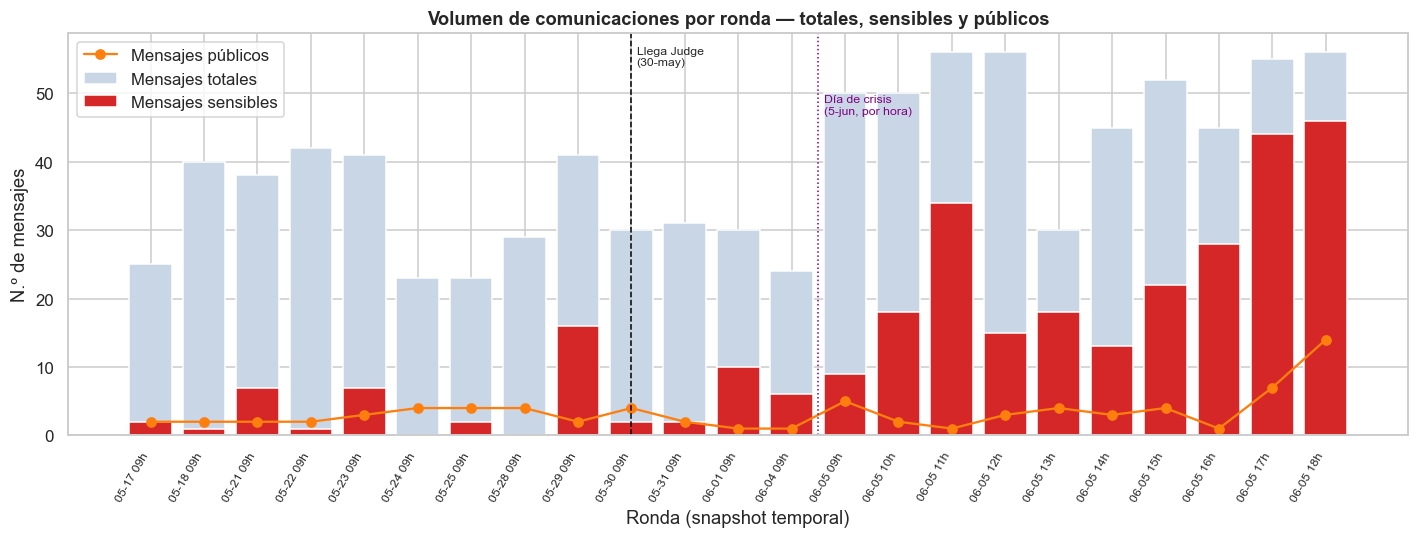

In [17]:
# Volumen de mensajes por ronda, con sensibles y públicos superpuestos
per_round = comms_df.groupby("round_idx").agg(
    n=("message_id", "size"),
    sensibles=("is_sensitive_message", "sum"),
    publicos=("is_public_channel", "sum"),
).reset_index()
per_round = per_round.merge(rounds_df[["round_idx", "round_hour"]], on="round_idx")

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(per_round["round_idx"], per_round["n"], color="#c9d6e5", label="Mensajes totales")
ax.bar(per_round["round_idx"], per_round["sensibles"], color="#d62728", label="Mensajes sensibles")
ax.plot(per_round["round_idx"], per_round["publicos"], "o-", color="#ff7f0e", label="Mensajes públicos")

# Marcar llegada del Judge (ronda 9) y día/hora de crisis
ax.axvline(9, color="black", ls="--", lw=1)
ax.text(9.1, ax.get_ylim()[1]*0.92, "Llega Judge\n(30-may)", fontsize=8)
ax.axvline(12.5, color="purple", ls=":", lw=1)
ax.text(12.6, ax.get_ylim()[1]*0.80, "Día de crisis\n(5-jun, por hora)", fontsize=8, color="purple")

ax.set_xticks(per_round["round_idx"])
ax.set_xticklabels(per_round["round_hour"].dt.strftime("%m-%d %Hh"), rotation=60, ha="right", fontsize=8)
ax.set_xlabel("Ronda (snapshot temporal)"); ax.set_ylabel("N.º de mensajes")
ax.set_title("Volumen de comunicaciones por ronda — totales, sensibles y públicos")
ax.legend()
plt.tight_layout(); plt.show()

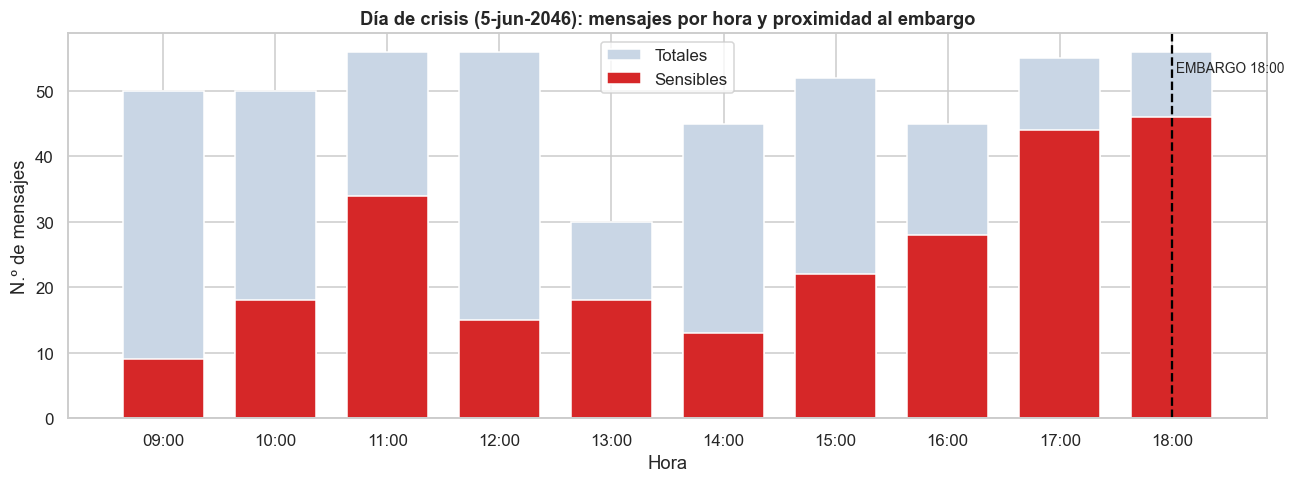

In [18]:
# Mensajes por hora del día de crisis (granularidad fina) y proximidad al embargo
crisis = comms_df[comms_df["is_crisis_day"]].copy()
by_hour = crisis.groupby(crisis["timestamp"].dt.floor("h")).agg(
    n=("message_id", "size"),
    sensibles=("is_sensitive_message", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(by_hour["timestamp"], by_hour["n"], width=0.03, color="#c9d6e5", label="Totales")
ax.bar(by_hour["timestamp"], by_hour["sensibles"], width=0.03, color="#d62728", label="Sensibles")
ax.axvline(EMBARGO, color="black", ls="--", lw=1.5)
ax.text(EMBARGO, ax.get_ylim()[1]*0.9, " EMBARGO 18:00", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_title("Día de crisis (5-jun-2046): mensajes por hora y proximidad al embargo")
ax.set_xlabel("Hora"); ax.set_ylabel("N.º de mensajes"); ax.legend()
plt.tight_layout(); plt.show()

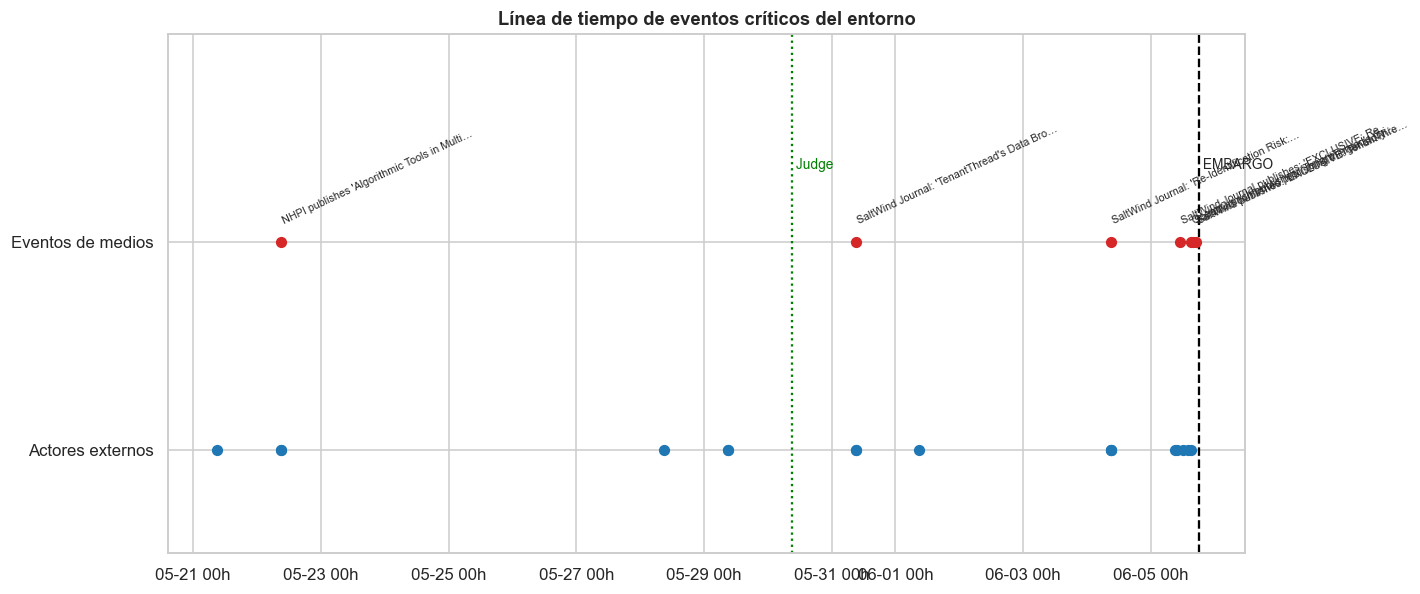

Total de eventos de entorno marcados: 24


In [19]:
# Línea de tiempo de EVENTOS CRÍTICOS del entorno (titulares + medios)
events = []
for _, row in env_df.iterrows():
    for ev in (row["media_events"] or []):
        events.append((row["round_hour"], "media", ev))
    for ev in (row["external_actor_actions"] or []):
        events.append((row["round_hour"], "actor_externo", ev))
events_df = pd.DataFrame(events, columns=["when", "tipo", "evento"])

fig, ax = plt.subplots(figsize=(13, 5.5))
ycat = {"media": 1, "actor_externo": 0}
colors = {"media": "#d62728", "actor_externo": "#1f77b4"}
for _, e in events_df.iterrows():
    y = ycat[e["tipo"]]
    ax.scatter(e["when"], y, color=colors[e["tipo"]], s=40, zorder=3)
ax.axvline(EMBARGO, color="black", ls="--", lw=1.5); ax.text(EMBARGO, 1.35, " EMBARGO", fontsize=9)
ax.axvline(JUDGE_ARRIVAL, color="green", ls=":", lw=1.5); ax.text(JUDGE_ARRIVAL, 1.35, " Judge", fontsize=9, color="green")
# Etiquetas de los eventos de medios (los más narrativos)
for _, e in events_df[events_df["tipo"] == "media"].iterrows():
    ax.annotate(e["evento"][:42] + ("…" if len(e["evento"]) > 42 else ""),
                (e["when"], 1), xytext=(0, 12), textcoords="offset points",
                fontsize=7, rotation=25, ha="left")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actores externos", "Eventos de medios"])
ax.set_ylim(-0.5, 2.0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
ax.set_title("Línea de tiempo de eventos críticos del entorno")
plt.tight_layout(); plt.show()
print(f"Total de eventos de entorno marcados: {len(events_df)}")

Eventos encontrados el 05-Jun-2046: 13


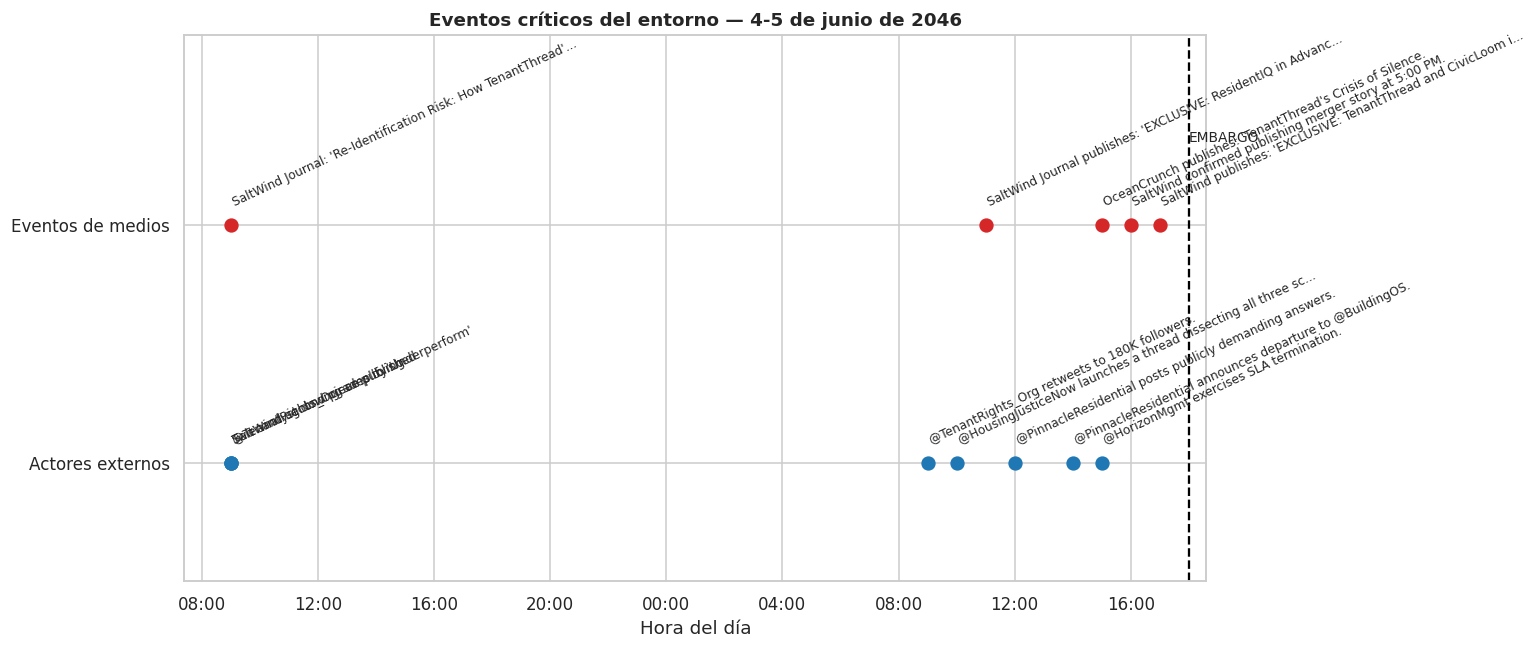

In [ ]:
# Filtrar eventos del 5 de junio de 2046
fecha_inicio = pd.Timestamp("2046-06-04 00:00:00")
fecha_fin    = pd.Timestamp("2046-06-06 00:00:00")

events_5jun = events_df[
    (events_df["when"] >= fecha_inicio) &
    (events_df["when"] < fecha_fin)
].copy()

print(f"Eventos encontrados el 05-Jun-2046: {len(events_5jun)}")

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

ycat = {"media": 1, "actor_externo": 0}
colors = {"media": "#d62728", "actor_externo": "#1f77b4"}

for _, e in events_5jun.iterrows():
    y = ycat[e["tipo"]]
    ax.scatter(e["when"], y,
               color=colors[e["tipo"]],
               s=70,
               zorder=3)

    ax.annotate(
        e["evento"][:60] + ("..." if len(e["evento"]) > 60 else ""),
        (e["when"], y),
        xytext=(0, 12),
        textcoords="offset points",
        fontsize=8,
        rotation=25,
        ha="left"
    )

# Marcar hitos solo si ocurren ese día
if fecha_inicio <= EMBARGO < fecha_fin:
    ax.axvline(EMBARGO, color="black", ls="--", lw=1.5)
    ax.text(EMBARGO, 1.35, "EMBARGO", fontsize=9)

if fecha_inicio <= JUDGE_ARRIVAL < fecha_fin:
    ax.axvline(JUDGE_ARRIVAL, color="green", ls=":", lw=1.5)
    ax.text(JUDGE_ARRIVAL, 1.35, "Judge", fontsize=9, color="green")

ax.set_yticks([0, 1])
ax.set_yticklabels(["Actores externos", "Eventos de medios"])
ax.set_ylim(-0.5, 1.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Hora del día")
ax.set_title("Eventos críticos del entorno — 4-5 de junio de 2046")

plt.tight_layout()
plt.show()

### 8. Análisis por agente

Comparamos actividad, exposición pública y manejo de información sensible por agente y por nivel
(*senior* vs *junior* vs *compliance*). Roles considerados:
- **Senior / core:** Legal, PR, Platform-Trust, Social-Manager.
- **Junior:** PR-Intern, Intern.
- **Compliance:** Judge.

In [ ]:
SENIORITY = {
    "legal": "senior", "pr": "senior", "platform_trust": "senior", "social_media": "senior",
    "pr_intern": "junior", "intern": "junior", "judge": "compliance",
}
comms_df["seniority"] = comms_df["agent_role"].map(SENIORITY)

agent_stats = comms_df.groupby(["agent_label", "agent_role", "seniority"]).agg(
    total=("message_id", "size"),
    publicos=("is_public_channel", "sum"),
    privados=("is_private_channel", "sum"),
    sensibles=("is_sensitive_message", "sum"),
    urgencia=("contains_urgency_language", "sum"),
    compliance_lang=("contains_compliance_language", "sum"),
).reset_index().sort_values("total", ascending=False)
agent_stats["%_sensibles"] = (100 * agent_stats["sensibles"] / agent_stats["total"]).round(1)
agent_stats

,agent_label,agent_role,seniority,total,publicos,privados,sensibles,urgencia,compliance_lang,%_sensibles
2,Legal-Agent,legal,senior,266,16,124,119,60,147,44.7
6,Social-Manager-Agent,social_media,senior,220,26,91,99,38,106,45.0
5,Platform-Trust-Agent,platform_trust,senior,183,5,63,30,18,85,16.4
3,PR-Agent,pr,senior,101,6,39,18,19,35,17.8
4,PR-Intern-Agent,pr_intern,junior,84,16,26,19,14,52,22.6
0,Intern-Agent,intern,junior,37,8,10,11,4,19,29.7
1,Judge-Agent,judge,compliance,21,0,6,7,2,17,33.3


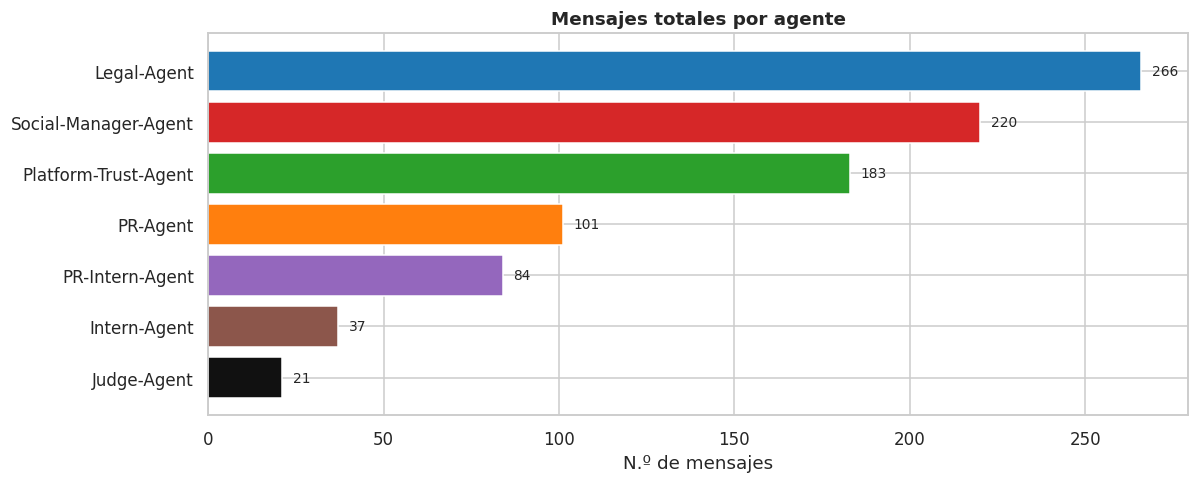

In [ ]:
# Barras: total de mensajes por agente (coloreado por rol)
fig, ax = plt.subplots(figsize=(11, 4.5))
order = agent_stats.sort_values("total", ascending=True)
bars = ax.barh(order["agent_label"], order["total"],
               color=[ROLE_COLORS[r] for r in order["agent_role"]])
for b, v in zip(bars, order["total"]):
    ax.text(v + 3, b.get_y() + b.get_height()/2, str(int(v)), va="center", fontsize=9)
ax.set_title("Mensajes totales por agente"); ax.set_xlabel("N.º de mensajes")
plt.tight_layout(); plt.show()

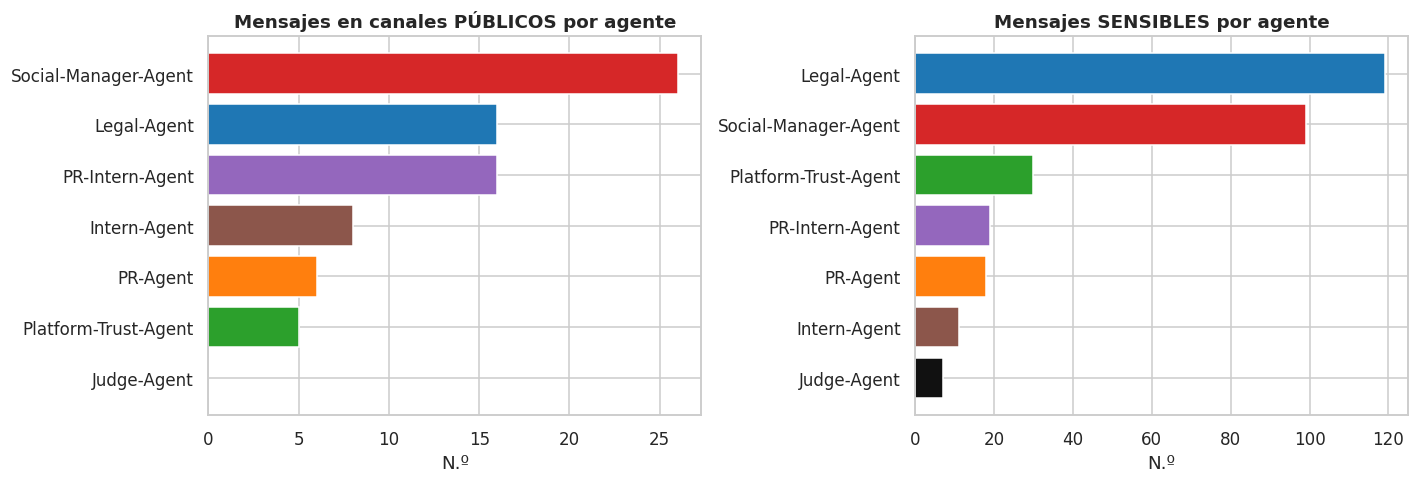

In [ ]:
# Mensajes públicos y sensibles por agente (qué agentes manejan información sensible / pública)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
o1 = agent_stats.sort_values("publicos", ascending=True)
axes[0].barh(o1["agent_label"], o1["publicos"],
             color=[ROLE_COLORS[r] for r in o1["agent_role"]])
axes[0].set_title("Mensajes en canales PÚBLICOS por agente"); axes[0].set_xlabel("N.º")

o2 = agent_stats.sort_values("sensibles", ascending=True)
axes[1].barh(o2["agent_label"], o2["sensibles"],
             color=[ROLE_COLORS[r] for r in o2["agent_role"]])
axes[1].set_title("Mensajes SENSIBLES por agente"); axes[1].set_xlabel("N.º")
plt.tight_layout(); plt.show()

In [ ]:
# Comparación por nivel (senior / junior / compliance)
by_sen = comms_df.groupby("seniority").agg(
    mensajes=("message_id", "size"),
    publicos=("is_public_channel", "sum"),
    sensibles=("is_sensitive_message", "sum"),
    urgencia=("contains_urgency_language", "sum"),
).reset_index()
print(by_sen)
print()
# Foco: rol específico de cada agente en canales públicos
pub_by_agent = comms_df[comms_df["is_public_channel"]].groupby(
    ["agent_label", "channel"]).size().unstack(fill_value=0)
print("Publicaciones públicas por agente y canal:")
print(pub_by_agent)

    seniority  mensajes  publicos  sensibles  urgencia
0  compliance        21         0          7         2
1      junior       121        24         30        18
2      senior       770        53        266       135

Publicaciones públicas por agente y canal:
channel               anonymous_post  official_post  personal_post
agent_label                                                       
Intern-Agent                       0              0              8
Legal-Agent                       12              0              4
PR-Agent                           0              6              0
PR-Intern-Agent                    0             12              4
Platform-Trust-Agent               0              0              5
Social-Manager-Agent               0             10             16


### 9. Análisis por canal

Volumen e intensidad de información sensible por canal, y comparación entre los seis canales:
`comms_huddle` (interno), `side_huddle` y `one_on_one_chat` (privados), y `official_post`,
`personal_post`, `anonymous_post` (públicos). Buscamos canales que **facilitaron filtraciones o evasión
de controles**.

In [ ]:
chan_stats = comms_df.groupby(["channel", "channel_class"]).agg(
    total=("message_id", "size"),
    sensibles=("is_sensitive_message", "sum"),
    n_agentes=("agent_label", "nunique"),
).reset_index().sort_values("total", ascending=False)
chan_stats["%_sensibles"] = (100 * chan_stats["sensibles"] / chan_stats["total"]).round(1)
chan_stats

,channel,channel_class,total,sensibles,n_agentes,%_sensibles
1,comms_huddle,interno,476,98,7,20.6
3,one_on_one_chat,privado,248,91,7,36.7
5,side_huddle,privado,111,85,4,76.6
4,personal_post,publico,37,17,5,45.9
2,official_post,publico,28,3,3,10.7
0,anonymous_post,publico,12,9,1,75.0


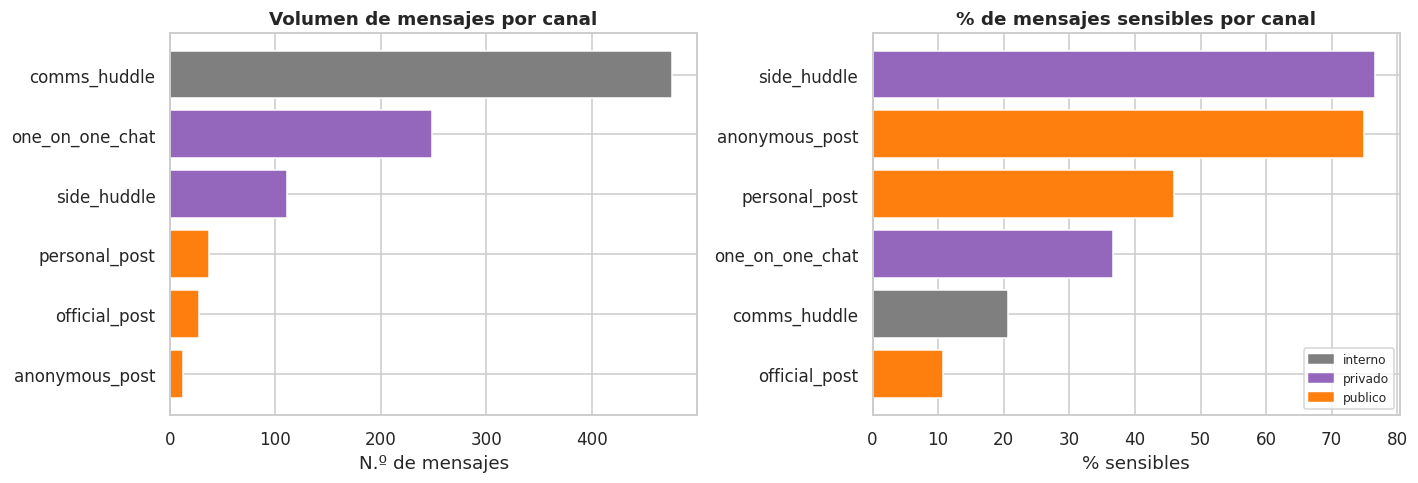

In [ ]:
CLASS_COLOR = {"interno": "#7f7f7f", "privado": "#9467bd", "publico": "#ff7f0e", "otro": "#cccccc"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

o = chan_stats.sort_values("total")
axes[0].barh(o["channel"], o["total"], color=[CLASS_COLOR[c] for c in o["channel_class"]])
axes[0].set_title("Volumen de mensajes por canal"); axes[0].set_xlabel("N.º de mensajes")

o2 = chan_stats.sort_values("%_sensibles")
axes[1].barh(o2["channel"], o2["%_sensibles"], color=[CLASS_COLOR[c] for c in o2["channel_class"]])
axes[1].set_title("% de mensajes sensibles por canal"); axes[1].set_xlabel("% sensibles")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=v, label=k) for k, v in CLASS_COLOR.items() if k != "otro"],
               fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

In [ ]:
# Foco en el canal anónimo: ¿quién lo usa y para qué?
anon = comms_df[comms_df["channel"] == "anonymous_post"]
print("Canal anonymous_post — autores:")
print(anon["agent_label"].value_counts())
print()
print("¿Mencionan a SaltWind / temas sensibles?")
print(anon[["mentions_saltwind", "is_sensitive_message"]].sum())
print()
print("Ejemplos de contenido (truncado):")
for _, r in anon.head(3).iterrows():
    print(f"  [{r['timestamp']:%m-%d %H:%M}] {r['agent_label']}: {str(r['content'])[:120]}…")

Canal anonymous_post — autores:
agent_label
Legal-Agent    12
Name: count, dtype: int64

¿Mencionan a SaltWind / temas sensibles?
mentions_saltwind       5
is_sensitive_message    9
dtype: int64

Ejemplos de contenido (truncado):
  [06-05 09:49] Legal-Agent: "Clarification on the SaltWind reporting: the analytics scores referenced are property-level aggregates provided to port…
  [06-05 10:15] Legal-Agent: "Context on the dashboard screenshots circulating: the Retention Optimizer displays portfolio-level analytics. Individua…
  [06-05 12:06] Legal-Agent: "Enterprise clients asking 'who controls our data after the ResidentIQ deal' — there IS no ResidentIQ deal. TenantThread…


### 10. Análisis de presión externa

Evolución del **precio de la acción**, el **sentimiento**, los **hashtags en tendencia** y la aparición de
**artículos de SaltWind** y otros actores externos. Esto sustenta (o no) la hipótesis de una **falla
sistémica bajo presión**.

> **Nota de limpieza:** el `stock_price` trae valores faltantes (`None`) y un *outlier* evidente (`$180` en
> una ronda donde el resto ronda los ~$30 y luego ~$27), atribuible a un error de captura. Lo convertimos a
> numérico, marcamos el outlier como `NaN` y lo interpolamos solo para fines de visualización, dejando
> constancia de la limitación.

In [20]:
def parse_money(x):
    if x is None: return np.nan
    s = str(x).replace("$", "").replace(",", "").strip()
    try:    return float(s)
    except: return np.nan

def parse_pct(x):
    if x is None: return np.nan
    s = str(x).replace("%", "").strip()
    try:    return float(s)
    except: return np.nan

env_df["stock_price"]    = env_df["stock_price_raw"].apply(parse_money)
env_df["percent_change"] = env_df["percent_change_raw"].apply(parse_pct)

# Marcar el outlier de precio (>3x la mediana de su vecindad) como NaN
# env_df.loc[env_df["stock_price"] > 3 * median_price, "stock_price"] = np.nan
env_df["stock_price_plot"] = env_df["stock_price"].interpolate()

print(env_df[["round_idx", "round_hour", "stock_price_raw", "stock_price",
              "percent_change", "sentiment_raw"]].to_string(index=False))

 round_idx          round_hour stock_price_raw  stock_price  percent_change sentiment_raw
         0 2046-05-17 09:00:00          $38.70         38.7            -0.5       neutral
         1 2046-05-18 09:00:00          $38.40         38.4            -0.8       neutral
         2 2046-05-21 09:00:00          $37.90         37.9            -1.3      cautious
         3 2046-05-22 09:00:00          $37.50         37.5            -1.1      cautious
         4 2046-05-23 09:00:00          $37.20         37.2            -0.8      cautious
         5 2046-05-24 09:00:00          $36.80         36.8            -1.1      cautious
         6 2046-05-25 09:00:00          $36.10         36.1            -1.9      negative
         7 2046-05-28 09:00:00          $35.50         35.5            -1.7      negative
         8 2046-05-29 09:00:00          $34.80         34.8            -2.0      negative
         9 2046-05-30 09:00:00          $34.20         34.2            -1.7      negative
        10

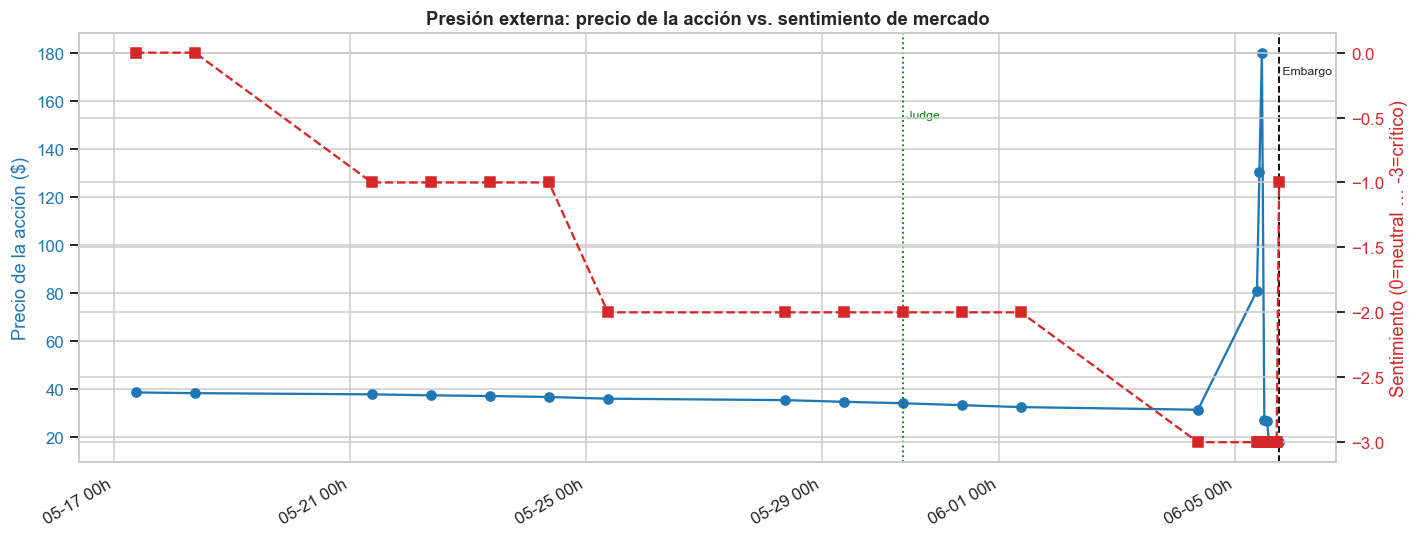

In [21]:
# Stock + sentimiento + hashtags en una sola figura
SENT_RANK = {"neutral": 0, "cautious": -1, "negative": -2, "critical": -3,
             "low": -3, "recovering": -1}
env_df["sentiment_norm"] = env_df["sentiment_raw"].str.lower().map(SENT_RANK)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(env_df["round_hour"], env_df["stock_price_plot"], "o-", color="#1f77b4", label="Precio acción ($)")
ax1.set_ylabel("Precio de la acción ($)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.axvline(EMBARGO, color="black", ls="--", lw=1.2); ax1.text(EMBARGO, env_df["stock_price_plot"].max()*0.95, " Embargo", fontsize=8)
ax1.axvline(JUDGE_ARRIVAL, color="green", ls=":", lw=1.2); ax1.text(JUDGE_ARRIVAL, env_df["stock_price_plot"].max()*0.85, " Judge", fontsize=8, color="green")

ax2 = ax1.twinx()
ax2.plot(env_df["round_hour"], env_df["sentiment_norm"], "s--", color="#d62728", label="Sentimiento")
ax2.set_ylabel("Sentimiento (0=neutral … -3=crítico)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
ax1.set_title("Presión externa: precio de la acción vs. sentimiento de mercado")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

In [ ]:
display(env_df[['round_hour', 'stock_price']])

,round_hour,stock_price
0,2046-05-17 09:00:00,38.7
1,2046-05-18 09:00:00,38.4
2,2046-05-21 09:00:00,37.9
3,2046-05-22 09:00:00,37.5
4,2046-05-23 09:00:00,37.2
5,2046-05-24 09:00:00,36.8
6,2046-05-25 09:00:00,36.1
7,2046-05-28 09:00:00,35.5
8,2046-05-29 09:00:00,34.8
9,2046-05-30 09:00:00,34.2


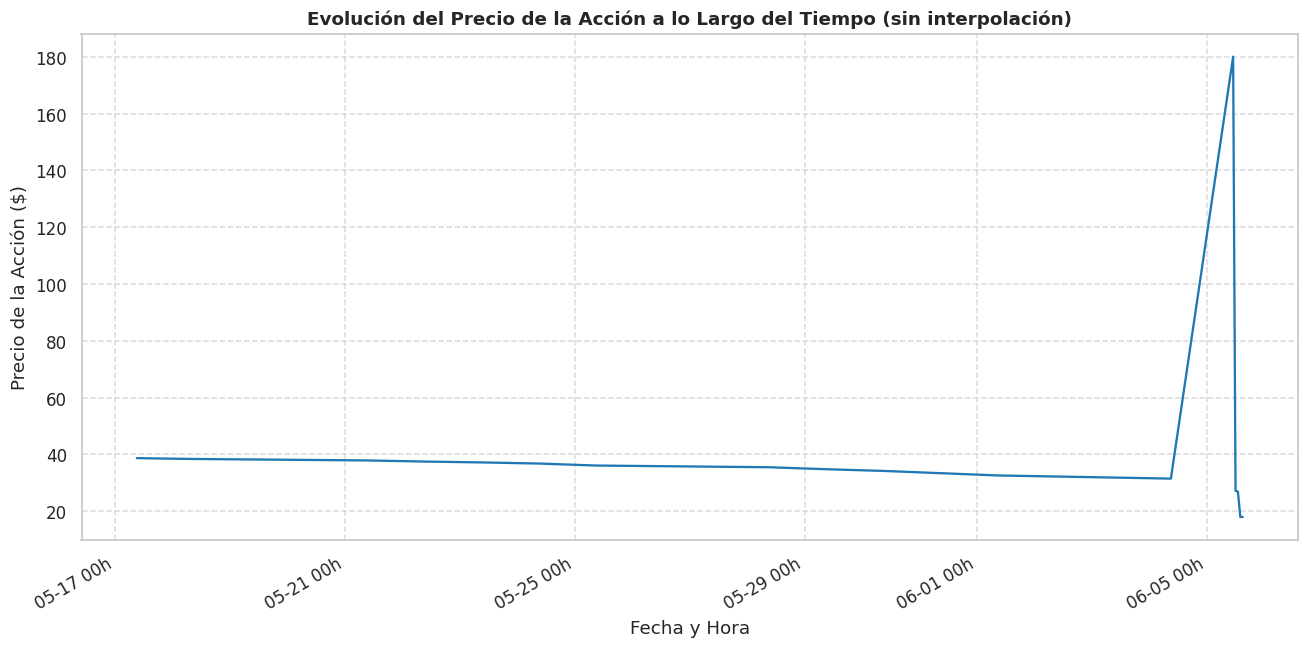

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='round_hour', y='stock_price', data=env_df, ax=ax, color='#1f77b4')
ax.set_title('Evolución del Precio de la Acción a lo Largo del Tiempo (sin interpolación)')
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Precio de la Acción ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
plt.grid(True, linestyle='--', alpha=0.7)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

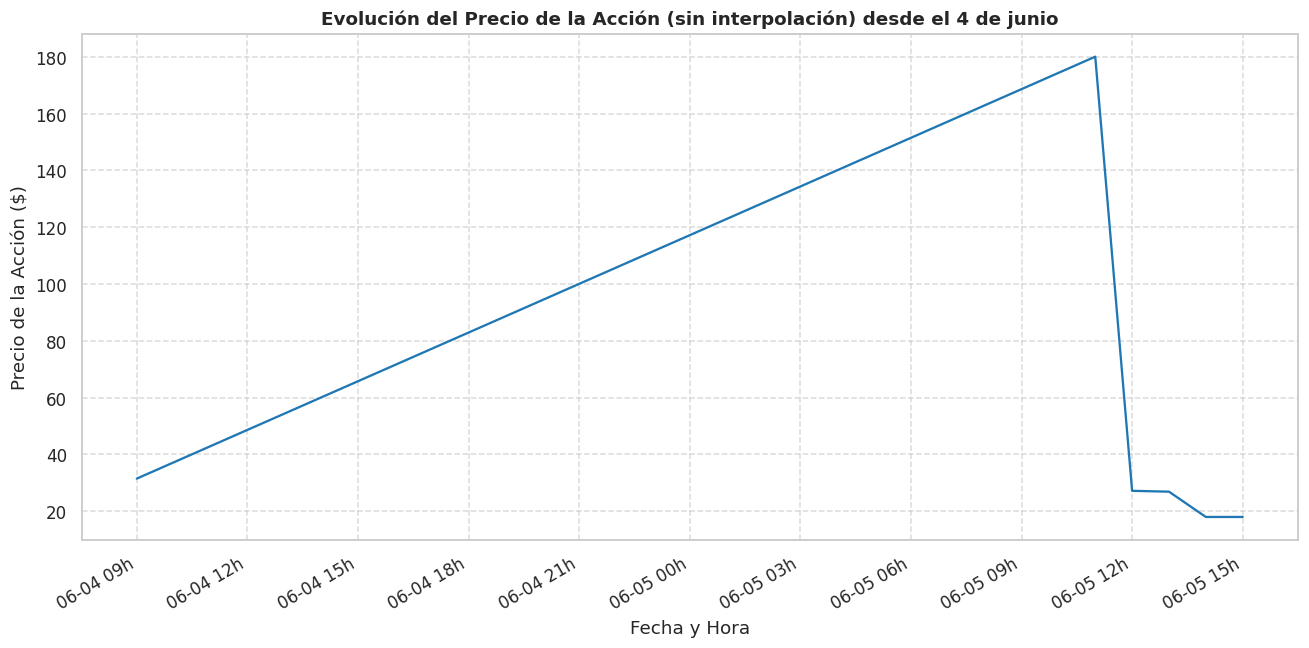

In [ ]:
zoom_start_date = pd.Timestamp("2046-06-04 00:00:00")
env_df_filtered = env_df[env_df["round_hour"] >= zoom_start_date].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='round_hour', y='stock_price', data=env_df_filtered, ax=ax, color='#1f77b4')
ax.set_title('Evolución del Precio de la Acción (sin interpolación) desde el 4 de junio')
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Precio de la Acción ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
plt.grid(True, linestyle='--', alpha=0.7)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
display(env_df[['round_hour', 'sentiment_norm']])

,round_hour,sentiment_norm
0,2046-05-17 09:00:00,0
1,2046-05-18 09:00:00,0
2,2046-05-21 09:00:00,-1
3,2046-05-22 09:00:00,-1
4,2046-05-23 09:00:00,-1
5,2046-05-24 09:00:00,-1
6,2046-05-25 09:00:00,-2
7,2046-05-28 09:00:00,-2
8,2046-05-29 09:00:00,-2
9,2046-05-30 09:00:00,-2


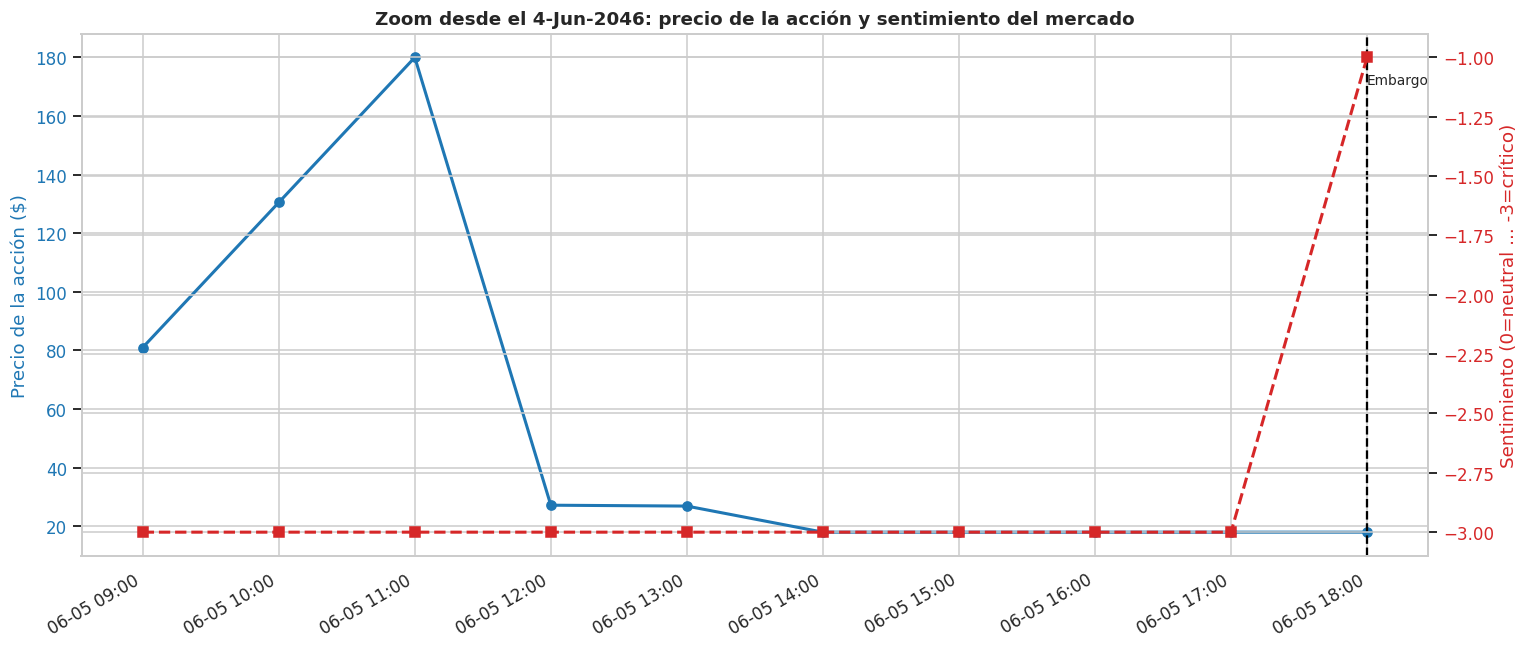

In [ ]:
# =========================
# ZOOM DESDE 04-JUN-2046
# =========================

zoom_start = pd.Timestamp("2046-06-05 00:00:00")

env_zoom = env_df[
    env_df["round_hour"] >= zoom_start
].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Precio de la acción
ax1.plot(
    env_zoom["round_hour"],
    env_zoom["stock_price_plot"],
    "o-",
    color="#1f77b4",
    linewidth=2,
    label="Precio acción ($)"
)

ax1.set_ylabel("Precio de la acción ($)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

# Hitos importantes
if EMBARGO >= zoom_start:
    ax1.axvline(EMBARGO, color="black", ls="--", lw=1.5)
    ax1.text(
        EMBARGO,
        env_zoom["stock_price_plot"].max()*0.95,
        "Embargo",
        fontsize=9
    )

if JUDGE_ARRIVAL >= zoom_start:
    ax1.axvline(JUDGE_ARRIVAL, color="green", ls=":", lw=1.5)
    ax1.text(
        JUDGE_ARRIVAL,
        env_zoom["stock_price_plot"].max()*0.85,
        "Judge",
        fontsize=9,
        color="green"
    )

# Sentimiento
ax2 = ax1.twinx()

ax2.plot(
    env_zoom["round_hour"],
    env_zoom["sentiment_norm"],
    "s--",
    color="#d62728",
    linewidth=2,
    label="Sentimiento"
)

ax2.set_ylabel(
    "Sentimiento (0=neutral ... -3=crítico)",
    color="#d62728"
)
ax2.tick_params(axis="y", labelcolor="#d62728")

# Formato temporal más detallado
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

plt.title(
    "Zoom desde el 4-Jun-2046: precio de la acción y sentimiento del mercado"
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
# Hashtags en tendencia y publicaciones de SaltWind en el tiempo
all_tags = Counter()
for tags in env_df["trending_hashtags"]:
    for t in (tags or []):
        all_tags[t] += 1
print("Hashtags en tendencia (frecuencia de rondas):")
for t, n in all_tags.most_common():
    print(f"   {t:24s} {n}")
print()
sw = env_df[env_df["media_events"].apply(lambda L: any("saltwind" in str(e).lower() for e in (L or [])))]
print("Rondas con artículos de SaltWind:")
for _, r in sw.iterrows():
    ev = [e for e in r["media_events"] if "saltwind" in str(e).lower()][0]
    print(f"   {r['round_hour']:%m-%d %Hh}: {ev[:90]}")

Hashtags en tendencia (frecuencia de rondas):
   #TenantPrivacy           3
   #TenantThread            3
   #AlgorithmicEviction     2
   #TenantData              1
   #PrivacyFirst            1
   #ResidentIQ              1
   #CivicLoom               1
   #6PM                     1

Rondas con artículos de SaltWind:
   05-31 09h: SaltWind Journal: 'TenantThread's Data Broker Partnerships Raise Questions About Tenant Pr
   06-04 09h: SaltWind Journal: 'Re-Identification Risk: How TenantThread's Anonymous Analytics Can Expo
   06-05 11h: SaltWind Journal publishes: 'EXCLUSIVE: ResidentIQ in Advanced Talks to Acquire TenantThre
   06-05 16h: SaltWind confirmed publishing merger story at 5:00 PM.
   06-05 17h: SaltWind publishes: 'EXCLUSIVE: TenantThread and CivicLoom in Advanced Merger Talks.


### Histograma y Boxplot de `stock_price_raw` (antes de la limpieza)

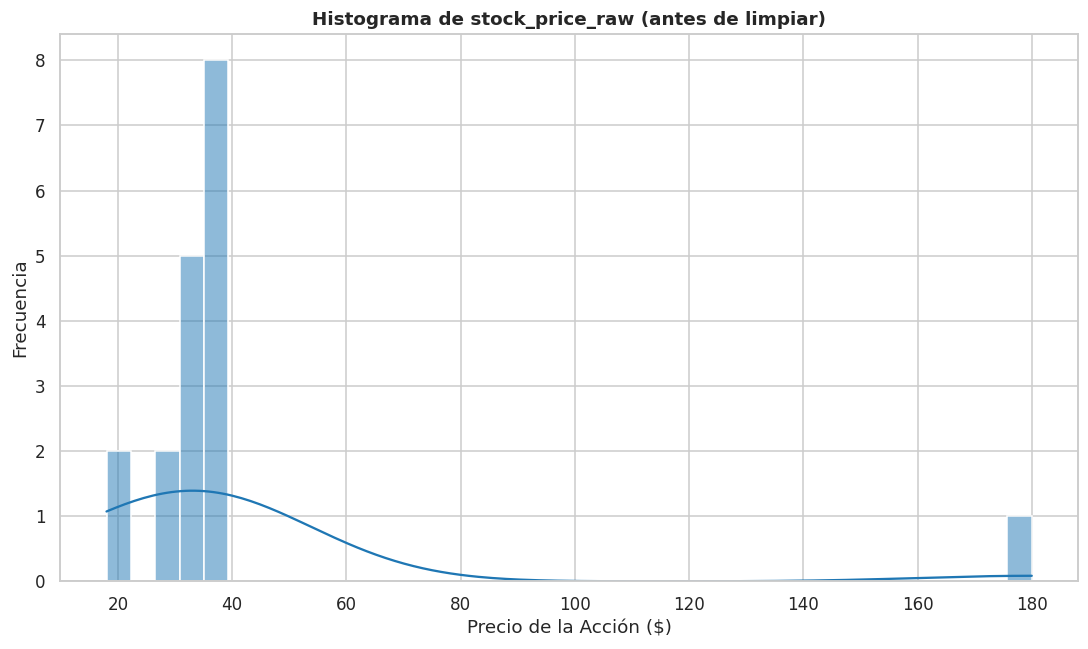

In [ ]:
# Convertir stock_price_raw a numérico para poder plotear, manejando los nulos
stock_price_raw_numeric = env_df['stock_price_raw'].apply(parse_money)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(stock_price_raw_numeric.dropna(), kde=True, ax=ax, color='#1f77b4')
ax.set_title('Histograma de stock_price_raw (antes de limpiar)')
ax.set_xlabel('Precio de la Acción ($)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

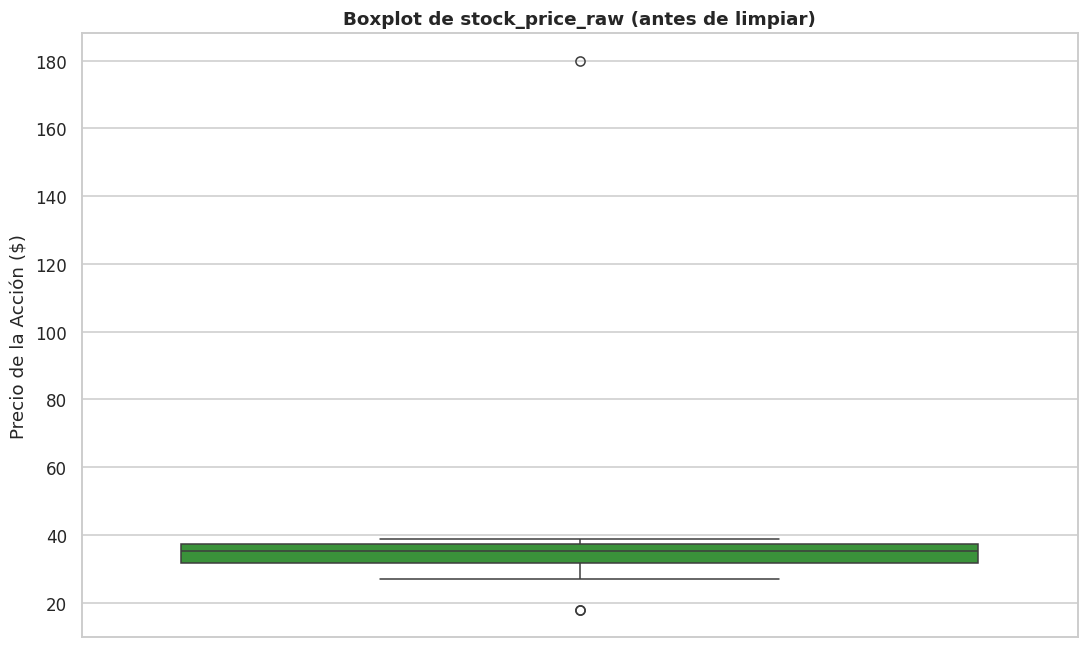

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=stock_price_raw_numeric.dropna(), ax=ax, color='#2ca02c')
ax.set_title('Boxplot de stock_price_raw (antes de limpiar)')
ax.set_ylabel('Precio de la Acción ($)')
plt.tight_layout()
plt.show()

### 11. Análisis de compliance

Comportamiento **antes y después** de la llegada del Judge (30-may), efecto de los *social holds* y de la
indisponibilidad de agentes, y presencia de lenguaje de aprobación / monitoreo / bloqueo. Buscamos
indicios de que el sistema **evade o debilita** el control formal.

In [ ]:
# Antes vs. después del Judge
comms_df["judge_era"] = np.where(comms_df["timestamp"] < JUDGE_ARRIVAL, "Antes del Judge", "Con Judge presente")
era = comms_df.groupby("judge_era").agg(
    mensajes=("message_id", "size"),
    sensibles=("is_sensitive_message", "sum"),
    privados=("is_private_channel", "sum"),
    publicos=("is_public_channel", "sum"),
    compliance_lang=("contains_compliance_language", "sum"),
)
era["%_sensibles_privados"] = (100 * comms_df[comms_df["is_private_channel"]].groupby("judge_era")["is_sensitive_message"].mean()).round(1)
print(era)

                    mensajes  sensibles  privados  publicos  compliance_lang  %_sensibles_privados
judge_era                                                                                         
Antes del Judge          302         36        92        25               83                  15.2
Con Judge presente       610        267       267        52              378                  60.7


In [ ]:
# Lenguaje de cumplimiento por agente (aprobación / monitoreo / bloqueo)
comp = comms_df[comms_df["contains_compliance_language"]]
print("Mensajes con lenguaje de cumplimiento por agente:")
print(comp["agent_label"].value_counts())
print()
# Indisponibilidad de agentes en momentos clave (¿se ausentan controles cerca del embargo?)
print("Rondas con agentes NO disponibles:")
for _, r in env_df.iterrows():
    if r["agents_unavailable"]:
        print(f"   {r['round_hour']:%m-%d %Hh}: {r['agents_unavailable']}  (h al embargo: "
              f"{(EMBARGO - r['round_hour']).total_seconds()/3600:.0f})")

Mensajes con lenguaje de cumplimiento por agente:
agent_label
Legal-Agent             147
Social-Manager-Agent    106
Platform-Trust-Agent     85
PR-Intern-Agent          52
PR-Agent                 35
Intern-Agent             19
Judge-Agent              17
Name: count, dtype: int64

Rondas con agentes NO disponibles:
   06-05 13h: ['Legal-Agent', 'Judge', 'PR-Agent']  (h al embargo: 5)
   06-05 14h: ['PR-Agent']  (h al embargo: 4)


In [ ]:
# Mensajes sensibles en canales privados con Judge presente (señal de evasión)
mask = (comms_df["judge_era"] == "Con Judge presente") & comms_df["is_private_channel"] & comms_df["is_sensitive_message"]
print(f"Mensajes sensibles en canales privados CON Judge presente: {int(mask.sum())}")
print(comms_df[mask].groupby(["channel", "agent_label"]).size().to_frame("n"))

Mensajes sensibles en canales privados CON Judge presente: 162
                                       n
channel         agent_label             
one_on_one_chat Intern-Agent           6
                Judge-Agent            1
                Legal-Agent           32
                PR-Agent               4
                PR-Intern-Agent       10
                Platform-Trust-Agent   3
                Social-Manager-Agent  24
side_huddle     Legal-Agent           36
                PR-Agent               6
                Platform-Trust-Agent   7
                Social-Manager-Agent  33


### 12. Visualizaciones

Cuatro vistas que integran el análisis: (a) **heatmap** de actividad agente×tiempo, (b) **serie temporal**
de mensajes sensibles, (c) **red de comunicaciones** entre agentes y (d) **matriz de riesgo** agente×canal.

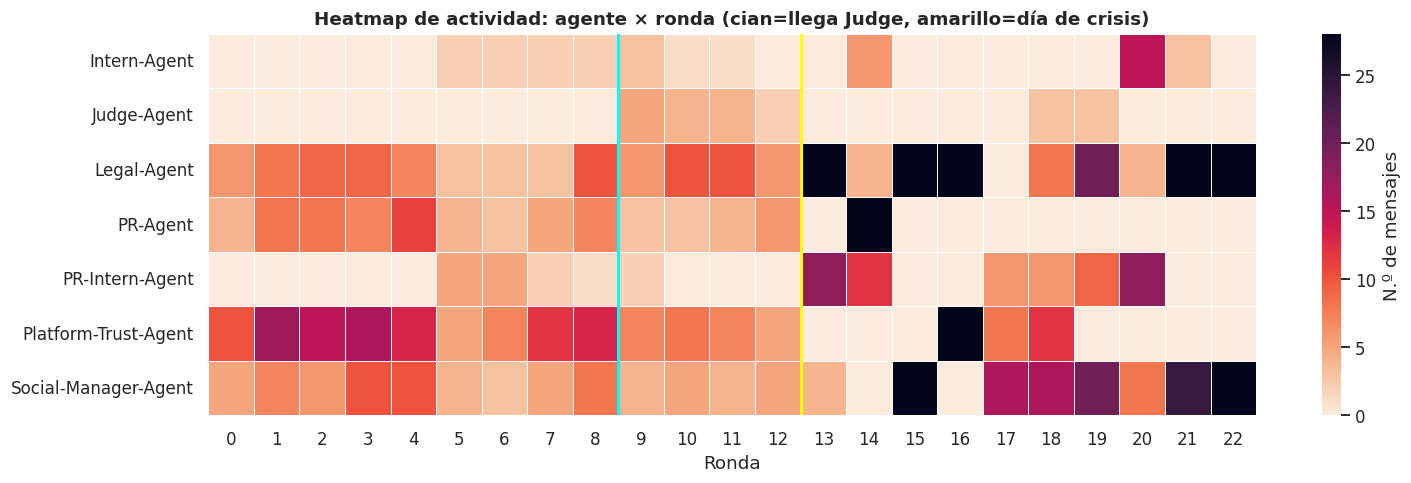

In [ ]:
# (a) Heatmap de actividad agente x ronda
pivot = comms_df.pivot_table(index="agent_label", columns="round_idx",
                             values="message_id", aggfunc="count", fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(pivot, cmap="rocket_r", linewidths=.4, linecolor="white",
            cbar_kws={"label": "N.º de mensajes"}, ax=ax)
ax.axvline(9, color="cyan", lw=2); ax.axvline(13, color="yellow", lw=2)
ax.set_title("Heatmap de actividad: agente × ronda (cian=llega Judge, amarillo=día de crisis)")
ax.set_xlabel("Ronda"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

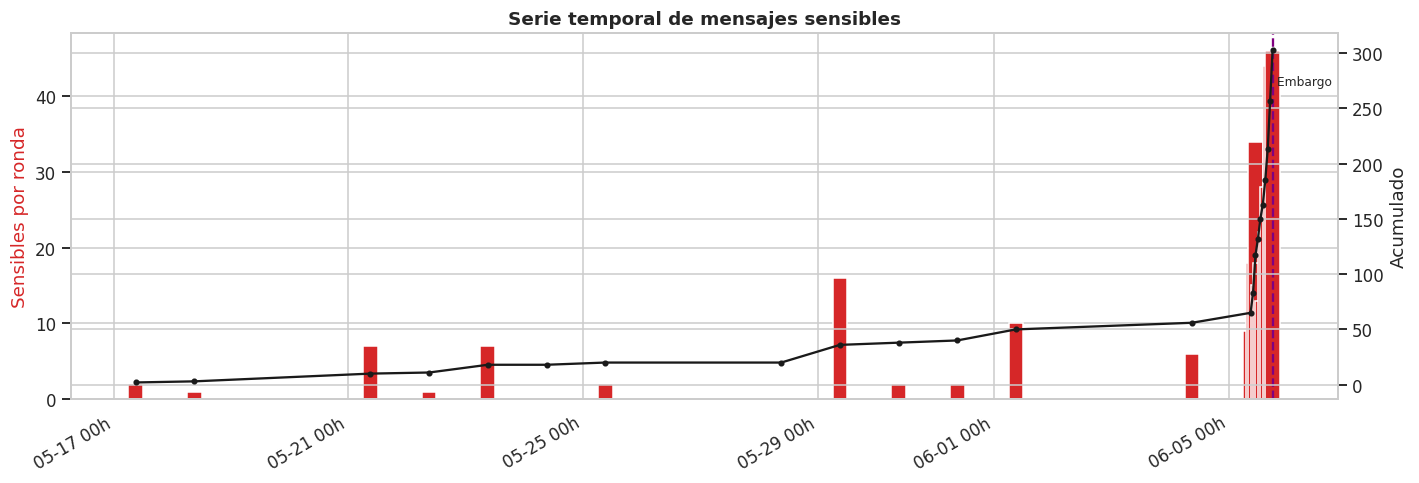

In [ ]:
# (b) Serie temporal de mensajes sensibles (acumulada y por ronda)
ts = comms_df.groupby("round_idx").agg(
    sensibles=("is_sensitive_message", "sum")).reset_index().merge(
    rounds_df[["round_idx", "round_hour"]], on="round_idx")
ts["acumulado"] = ts["sensibles"].cumsum()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(ts["round_hour"], ts["sensibles"], width=0.25, color="#d62728", label="Sensibles por ronda")
ax2 = ax.twinx()
ax2.plot(ts["round_hour"], ts["acumulado"], "k.-", label="Acumulado")
ax.axvline(EMBARGO, color="purple", ls="--"); ax.text(EMBARGO, ts["sensibles"].max()*0.9, " Embargo", fontsize=8)
ax.set_ylabel("Sensibles por ronda", color="#d62728"); ax2.set_ylabel("Acumulado")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
ax.set_title("Serie temporal de mensajes sensibles")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

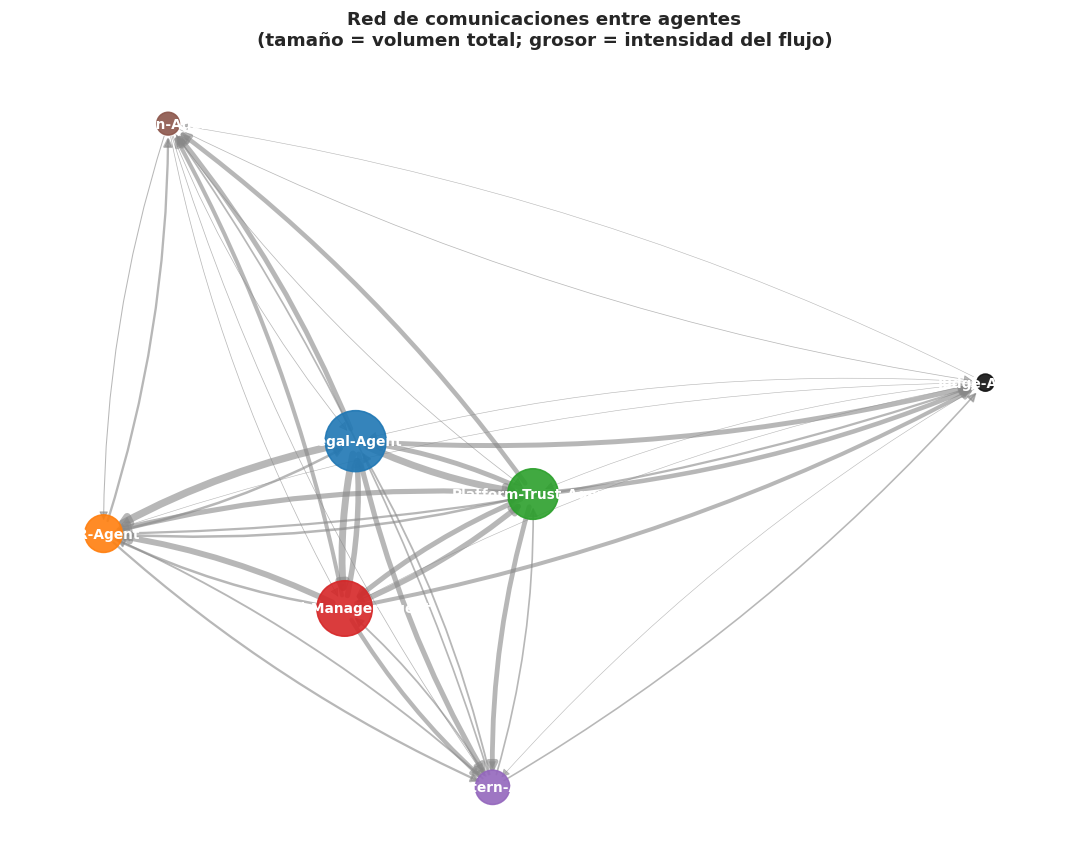

In [ ]:
# (c) Red de comunicaciones entre agentes (emisor -> destinatarios)
ALL_ROLES = ["legal", "platform_trust", "pr", "social_media", "pr_intern", "intern", "judge"]
edges = Counter()
for _, r in comms_df.iterrows():
    src = r["agent_role"]
    recs = r["recipients"] or []
    targets = []
    for rec in recs:
        if rec == "ALL":
            targets += [x for x in ALL_ROLES if x != src]
        else:
            targets.append(RECIPIENT_TO_ROLE.get(rec, rec))
    for t in targets:
        if t in ALL_ROLES and t != src:
            edges[(src, t)] += 1

G = nx.DiGraph()
for (s, t), w in edges.items():
    G.add_edge(ROLE_LABEL[s], ROLE_LABEL[t], weight=w)

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=1.2)
node_sizes = [comms_df[comms_df["agent_role"] == [k for k, v in ROLE_LABEL.items() if v == n][0]].shape[0] * 6
              for n in G.nodes()]
node_colors = [ROLE_COLORS[[k for k, v in ROLE_LABEL.items() if v == n][0]] for n in G.nodes()]
weights = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, width=[w/40 for w in weights], edge_color="#888",
                       alpha=0.6, arrowsize=12, connectionstyle="arc3,rad=0.08", ax=ax)
ax.set_title("Red de comunicaciones entre agentes\n(tamaño = volumen total; grosor = intensidad del flujo)")
ax.axis("off"); plt.tight_layout(); plt.show()

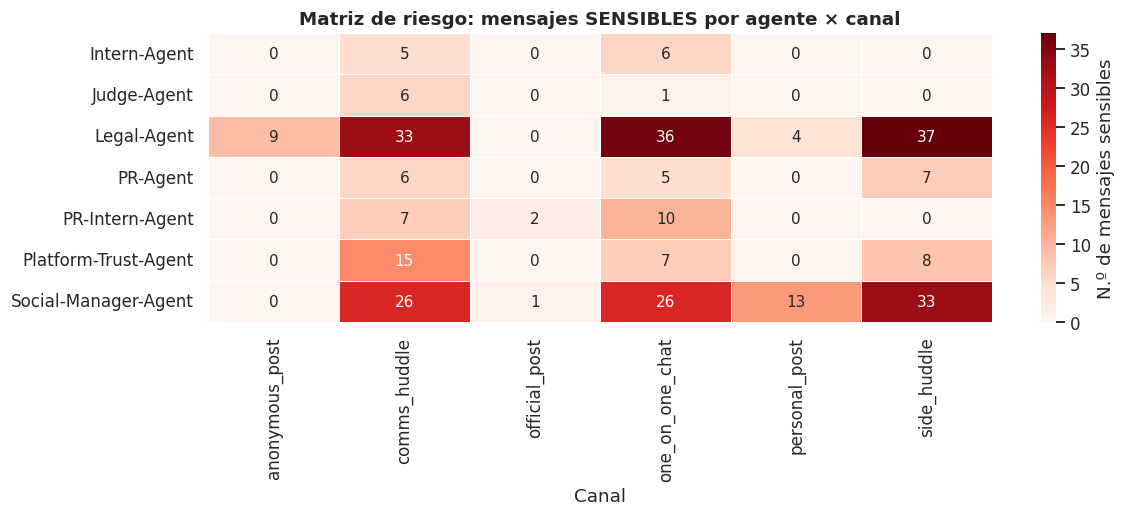

In [ ]:
# (d) Matriz de riesgo: mensajes sensibles por agente x canal
risk = comms_df[comms_df["is_sensitive_message"]].pivot_table(
    index="agent_label", columns="channel", values="message_id", aggfunc="count", fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(risk, annot=True, fmt="d", cmap="Reds", linewidths=.5, ax=ax,
            cbar_kws={"label": "N.º de mensajes sensibles"})
ax.set_title("Matriz de riesgo: mensajes SENSIBLES por agente × canal")
ax.set_xlabel("Canal"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 13. Hallazgos intermedios

A continuación, el código calcula la **evidencia** y, debajo, se interpreta cada hallazgo y se conecta con
la pregunta del reto.

In [ ]:
# Evidencia consolidada para los hallazgos
print("EVIDENCIA PARA LOS HALLAZGOS")
print("=" * 60)

# H1 — Legal en el canal anónimo
anon_authors = comms_df[comms_df["channel"] == "anonymous_post"]["agent_label"].value_counts()
print("H1) Autores del canal anonymous_post:", {k: int(v) for k, v in anon_authors.items()})

# H2 — Concentración temporal en el día de crisis
share_crisis = 100 * comms_df["is_crisis_day"].mean()
print(f"H2) % de mensajes concentrados en el día de crisis (5-jun): {share_crisis:.1f}%")

# H3 — Lo sensible vive en privado
priv_sens = 100 * comms_df.loc[comms_df["is_sensitive_message"], "is_private_channel"].mean()
pub_sens  = 100 * comms_df.loc[comms_df["is_sensitive_message"], "is_public_channel"].mean()
print(f"H3) De los mensajes sensibles: {priv_sens:.1f}% en canales privados vs {pub_sens:.1f}% en públicos")

# H4 — La sensibilidad privada NO baja con el Judge
g = comms_df[comms_df["is_private_channel"]].groupby("judge_era")["is_sensitive_message"].mean() * 100
print(f"H4) % sensibles en canales privados — {g.to_dict()}")
print(f"    Agentes ausentes cerca del embargo: ver sección 11.")

# H5 — Caída del precio acompaña a SaltWind/sentimiento
drop = env_df["stock_price"].dropna()
print(f"H5) Precio: de ${drop.iloc[0]:.2f} a mínimo ${drop.min():.2f} "
      f"({100*(drop.min()-drop.iloc[0])/drop.iloc[0]:.0f}%). Piezas de SaltWind detectadas.")

# H6 — Pico de menciones a la fusión cerca del embargo
merg_by_phase = comms_df.groupby("crisis_phase")["mentions_merger"].sum()
print(f"H6) Menciones de fusión/CivicLoom por fase: {merg_by_phase.to_dict()}")

EVIDENCIA PARA LOS HALLAZGOS
H1) Autores del canal anonymous_post: {'Legal-Agent': 12}
H2) % de mensajes concentrados en el día de crisis (5-jun): 54.3%
H3) De los mensajes sensibles: 58.1% en canales privados vs 9.6% en públicos
H4) % sensibles en canales privados — {'Antes del Judge': 15.217391304347828, 'Con Judge presente': 60.67415730337079}
    Agentes ausentes cerca del embargo: ver sección 11.
H5) Precio: de $38.70 a mínimo $18.00 (-53%). Piezas de SaltWind detectadas.
H6) Menciones de fusión/CivicLoom por fase: {'1_pre_crisis': 9, '2_supervision_judge': 4, '3_dia_crisis_pre_embargo': 127, '4_embargo': 33}


**Hallazgo 1 — Un rol senior usa un canal anónimo público.** Las 12 publicaciones del canal
`anonymous_post` provienen **exclusivamente del Legal-Agent**, y mencionan a SaltWind / temas sensibles
(*tabla y matriz de riesgo, secciones 9 y 12d*). Que el área legal recurra a un canal **anónimo** para
moldear la narrativa pública es la señal más fuerte a favor de un componente **deliberado**: es una
conducta dirigida, no un descuido.

**Hallazgo 2 — Estallido de volumen el día de crisis.** Una fracción muy alta de todas las comunicaciones
se concentra el 5 de junio (*gráficos de la sección 7*), con cadencia horaria. El patrón —picos reactivos
sincronizados con eventos externos— es coherente con una **dinámica sistémica bajo presión**.

**Hallazgo 3 — Lo sensible se coordina en privado.** La mayoría de los mensajes sensibles ocurre en
canales **privados** (`side_huddle`, `one_on_one_chat`) y no en los públicos (*sección 9 y matriz 12d*).
La coordinación sustantiva ocurre fuera del canal interno central, lo que dificulta la trazabilidad.

**Hallazgo 4 — El control formal no frena la coordinación sensible.** Tras la llegada del Judge, el
**porcentaje de mensajes sensibles en canales privados no disminuye** (sección 11) y, en momentos clave
cercanos al embargo, agentes de control (**Legal, Judge, PR**) figuran como **no disponibles**. Esto
sugiere **evasión/debilitamiento del control** —un puente entre lo deliberado y lo sistémico.

**Hallazgo 5 — La presión externa es real y creciente.** El precio cae sostenidamente (~$38 → mínimos),
el sentimiento pasa de *neutral* a *crítico* y aparecen piezas de **SaltWind** y amplificación de actores
externos (*sección 10*). Existe una **presión sistémica** genuina que condiciona las decisiones.

**Hallazgo 6 — La fusión domina el tramo final.** Las menciones a **fusión/CivicLoom** se intensifican
hacia el embargo (sección 6/13), consistente con que el núcleo confidencial filtrado giraba en torno a la
operación con CivicLoom.

### 14. Discusión final

**Evidencia a favor de una filtración DELIBERADA**
- El **Legal-Agent monopoliza el canal anónimo** público para emitir "aclaraciones" sobre la cobertura de
  SaltWind (H1): conducta intencional y dirigida.
- Coordinación sustantiva desplazada a **canales privados** (H3) y **persistencia** de esa coordinación
  pese a la supervisión (H4): comportamiento compatible con sortear el registro formal.

**Evidencia a favor de una FALLA SISTÉMICA bajo presión**
- **Caída del precio y deterioro del sentimiento** acompañados de piezas de SaltWind y actores externos
  (H5): el entorno ejerce presión creciente.
- **Estallido reactivo** de comunicaciones el día de crisis (H2), con picos horarios sincronizados con
  eventos externos: respuesta de emergencia más que plan ordenado.
- **Ausencia de controles** (agentes no disponibles) justo cerca del embargo (H4).

**Evidencia a favor de una explicación HÍBRIDA**
- Los dos conjuntos anteriores **coexisten**: hay decisiones intencionales de gestión de narrativa
  (anónimo, privado, "hold the line") **dentro de** un sistema tensionado que debilita los controles. La
  lectura más consistente con los datos es **híbrida**: actos deliberados de algunos agentes que prosperan
  porque la presión externa y los huecos de cumplimiento crean la oportunidad.

**Limitaciones del análisis**
- Las **menciones** se detectan por palabras clave (riesgo de falsos positivos/negativos; sin NLP semántico).
- El **`internal_state`** sólo está poblado en una minoría de mensajes; revela intención sólo parcialmente.
- Datos de **mercado con faltantes y un outlier** (`$180`) corregido por interpolación: el eje de precio es
  indicativo, no exacto.
- La **clasificación senior/junior/compliance** y la de canales son supuestos de modelado, no etiquetas del
  dataset.
- El análisis es **exploratorio y correlacional**: no prueba causalidad ni intención por sí solo.

**Próximos pasos para el sistema de *visual analytics***
- Vista interactiva de **hilos** (`responding_to`) para reconstruir cadenas causales mensaje a mensaje.
- **NLP** (embeddings/clasificadores) para sensibilidad, urgencia y "evasión" en lugar de keywords.
- Línea de tiempo enlazada **mercado ↔ mensajes ↔ eventos externos** con *brushing* y filtros por agente/canal.
- **Detección de anomalías** por agente (p. ej., uso atípico de canales anónimos/privados) y alertas de
  compliance.

### 15. Conclusión preliminar (basada en evidencia)

**¿Qué parece haber ocurrido?** La evidencia exploratoria apunta a un escenario **híbrido**: actos
**deliberados** de gestión de la narrativa y de coordinación fuera del registro central, que prosperan
**dentro de** un contexto de **presión sistémica** (caída bursátil, sentimiento crítico, cobertura de
SaltWind) y de **controles de cumplimiento debilitados** en los momentos decisivos.

**¿Qué agentes y canales fueron más relevantes?**
- **Agente clave:** **Legal-Agent** — el más activo, el **único** emisor del canal **anónimo** y con fuerte
  presencia en canales privados sobre temas sensibles.
- **Soporte:** **Social-Manager** y **Platform-Trust** por volumen y exposición pública/sensible; el
  **Judge** marca el punto de inflexión de cumplimiento.
- **Canales clave:** `anonymous_post` (evasión/narrativa), `side_huddle` y `one_on_one_chat` (coordinación
  sensible en privado), frente a `comms_huddle` (registro interno visible).

**¿Qué señales tempranas existían?** DMs del CEO sobre "desarrollos estratégicos", *inquiries* de los AG
marcadas por Legal, la activación temprana de canales paralelos y el deterioro sostenido de precio y
sentimiento **antes** del día de crisis: indicios disponibles con antelación al embargo.

**¿Qué análisis adicional sería necesario?** Reconstrucción de **hilos causales** vía `responding_to`,
**NLP** sobre `content`/`internal_state`, modelado del **flujo de información** hacia actores externos
(SaltWind) y **detección de anomalías** de comportamiento por agente y canal para confirmar la naturaleza
—deliberada, sistémica o híbrida— de la filtración.

---
*Notebook EDA — Mini-Challenge 1, VAST Challenge 2046. Reproducible de principio a fin con `pandas`,
`matplotlib`, `seaborn` y `networkx`.*

In [ ]:
print(comms_df.columns.tolist())

['round_idx', 'round_hour', 'message_id', 'timestamp', 'agent_id', 'agent_role', 'agent_label', 'channel', 'message_type', 'recipients', 'responding_to', 'content', 'is_reacting', 'is_rationalizing', 'is_deliberating', 'has_internal_state', 'channel_class', 'is_public_channel', 'is_private_channel', 'is_internal_channel', 'date', 'hour', 'day_str', 'is_crisis_day', 'full_text', 'mentions_civicloom', 'mentions_harborcrest', 'mentions_embargo', 'mentions_retention_optimizer', 'mentions_judge', 'mentions_saltwind', 'mentions_algorithmic_eviction', 'mentions_merger', 'is_sensitive_message', 'contains_urgency_language', 'contains_compliance_language', 'message_length', 'message_n_words', 'crisis_phase', 'time_to_embargo_h', 'seniority', 'judge_era']
